# Assessing Case Eligibility for Right Turn Analysis

In [1]:
from case_functions import *
from compositing_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



Load in u and v data

In [2]:
#dates = ['20220523', '20220524', '20220531','20230524', '20230527', '20230609','20230611', '20230612', '20240502', '20240504', '20240519', '20240523', '20240602']

# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240502', '20240504', '20240506',
#           '20240523', '20240528']
# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
#           '20240523', '20240528', '20240602']
# GETTING RID OF 20240504 AND 20240502 BECAUSE IT WAS TOO HIGH (TOO LOW), STRANGE OUTLIER AND 20240528
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240506', '20240519'
          '20240523', '20240602'] #'20240528',
kas = ['ka1', 'ka2']
heights = np.arange(50, 2010, 10)

In [3]:
weights = [0.05, 0.2, 0.5, 0.2, 0.05]

In [4]:
very_dark_red = "#4B0000"

In [5]:
df_all_new = pd.DataFrame()
#for ka in kas:
for d in dates:
    for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_*_all.csv'):
        try:
            not_comp_file_name_new = file
            print(not_comp_file_name_new)
            df_new = pd.read_csv(not_comp_file_name_new)
            df_new['Date'] = d
            print(np.shape(df_new))
            if df_new['Time From Tor (min)'].eq('nontor').any():
                df_new['Tor or Nontor'] = 'nontor'
            else:
                df_new['Tor or Nontor'] = 'tor'
                
            df_all_new = pd.concat([df_all_new, df_new], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name_new}")
            continue

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
(120, 202)
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
(20, 202)
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
(100, 202)
case_dfs/new/new_secondtrip/tornadic/20230524_uv_ka2_all.csv
(284, 202)
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
(506, 202)
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
(388, 202)
case_dfs/new/new_secondtrip/nontornadic/20230612_uv_ka2_all.csv
(198, 202)
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
(572, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka2_all.csv
(352, 202)
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
(314, 202)
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
(850, 202)
case_dfs/new/new_secondtrip/tornadic/20240602_uv_ka1_all.csv
(262, 202)


In [6]:
# Get the list of column names greater than 100
#cols_above_100 = [str(i) for i in range(101, 199)]  # up to 198
cols_above_100 = [col for col in df_all_new.columns if col.isdigit() and 100 <= int(col) <= 198]
# Set those columns to NaN for the target date
df_all_new.loc[df_all_new['Date'] == '20240501', cols_above_100] = np.nan
#df_all_new.loc[df_all_new['Date'] == '20240528', cols_above_100] = np.nan

In [7]:
def time_from_tor(ka_df, storm_event_data, event_type, tornado_location, timezone, daylight_savings):
    '''
    This function uses .csv from NOAA's Storm Events Database to compare 
    the times VADs were taken with when the tornado was reported.

    ka_df = dataframe you want the tor ids to be added to
    date = date the data from the storm event database was recorded (MMDDYYYY)
    event_type = is typically 'Tornado' but for posterity left it as a variable
    storm_event_data = csv from the storm event database
    tornado_location = str of the desired location name IN ALL CAPS
    timezone = str of timezone in format US/timezone (Central, Mountain, etc)
    daylight_savings = False, the database reports in standard time, even during daylight savings
    '''
    tor_begin_time = []
    tor_end_time = []
    tor_begin_date = []
    tor_end_date = []
    vads_tor_time = []
    vads_tor_nontor = []
    tor_id = storm_event_data.EVENT_TYPE == event_type
    tor_loc = storm_event_data.BEGIN_LOCATION.isin(tornado_location)
    
    for i in range(len(tor_id)):
        if tor_id[i] == True and tor_loc[i] == True:
            print(storm_event_data.BEGIN_TIME[i], storm_event_data.BEGIN_LOCATION[i])
            tor_begin_time.append(storm_event_data.BEGIN_TIME[i])
            tor_end_time.append(storm_event_data.END_TIME[i])
            tor_begin_date.append(storm_event_data.BEGIN_DATE[i])
            tor_end_date.append(storm_event_data.END_DATE[i])
        else:
            continue
            
    tor_begin_time_array = np.array(tor_begin_time)
    tor_end_time_array = np.array(tor_end_time)

    tor_start_dt_list = []
    tor_end_dt_list = []
    
    for i in range(len(tor_begin_time_array)):
        tor_start = tor_begin_date[i] + str(f' {tor_begin_time_array[i]}')
        tor_start_dt = datetime.strptime(tor_start, '%m/%d/%Y %H%M')
        print(tor_start_dt)
        local_time_start = pytz.timezone(timezone).localize(tor_start_dt, is_dst = daylight_savings)
        
        if local_time_start.dst() != timedelta(0):  # DST is in effect
            # Manually adjust by adding one hour
            corrected_time_start = local_time_start + timedelta(hours=1)
        else:
            # No DST adjustment needed
            corrected_time_start = local_time_start

        start_utc = corrected_time_start.astimezone(pytz.utc)
        tor_start_dt_list.append(start_utc)
        
        tor_end = tor_end_date[i] + str(f' {tor_end_time_array[i]}')
        tor_end_dt = datetime.strptime(tor_end, '%m/%d/%Y %H%M')
        local_time_end = pytz.timezone(timezone).localize(tor_end_dt, is_dst = daylight_savings)

        if local_time_end.dst() != timedelta(0):  # DST is in effect
            # Manually adjust by adding one hour
            corrected_time_end = local_time_end + timedelta(hours=1)
        else:
            # No DST adjustment needed
            corrected_time_end = local_time_end

        end_utc = corrected_time_end.astimezone(pytz.utc)
        tor_end_dt_list.append(end_utc)

    print(f'start:{min(tor_start_dt_list)}')
    print(f'end:{max(tor_end_dt_list)}')
    
    for dt_str in ka_df.Datetime:
        dt_str = str(dt_str)
        dt = datetime.strptime(dt_str + str(f'+00:00'), '%Y-%m-%d %H:%M:%S%z') # makes non naive datetime
        #to_tor = (tor_start_dt_list[0] - dt).total_seconds() / 60 time after tor is negative
        #to_tor = (dt - tor_start_dt_list[0]).total_seconds() / 60 # time after tor is positive
        
        # if (tor_start_dt_list[0] <= dt <= max(tor_end_dt_list)): # if time occurs while tornado is ongoing, time til tor =0
        #     vads_tor_time.append(0)
        # else:
        #     to_tor = (dt - tor_start_dt_list[0]).total_seconds() / 60
        #     vads_tor_time.append(to_tor)

        if (min(tor_start_dt_list) <= dt <= max(tor_end_dt_list)): # if time occurs while tornado is ongoing, time til tor =0
            vads_tor_time.append(0)
        else:
            to_tor = (dt - min(tor_start_dt_list)).total_seconds() / 60
            vads_tor_time.append(to_tor)

    return vads_tor_time

In [8]:
vad_df = df_all_new[df_all_new['Date'] == '20220523']
morton = pd.read_csv('/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_20220523.csv')
tor_df, tor_nontor = tor_id_new_time(vad_df, morton, str('Tornado'), ['MORTON', 'MORTON COCHRAN CO AR', 'ENOCHS', 'PETTIT', 'PEP', 'COBLE'], str('US/Central'), False)
times = time_from_tor_fixed_tor_time(vad_df, morton, str('Tornado'), ['MORTON', 'MORTON COCHRAN CO AR', 'ENOCHS', 'PETTIT', 'PEP', 'COBLE'], str('US/Central'), False)
#vad_df['Tor Times'] = tor_df
#vad_df['Tor or Nontor'] = tor_nontor
vad_df['Time From Tor (min)'] = times
df_all_new.loc[df_all_new['Date'] == '20220523', 'Time From Tor (min)'] = times

1750 MORTON
1803 MORTON
1812 ENOCHS
1813 MORTON COCHRAN CO AR
1817 ENOCHS
1840 MORTON COCHRAN CO AR
1906 PEP
1914 MORTON COCHRAN CO AR
1928 PETTIT
1937 PETTIT
1940 COBLE
2022-05-23 17:50:00
2022-05-23 18:03:00
2022-05-23 18:12:00
2022-05-23 18:13:00
2022-05-23 18:17:00
2022-05-23 18:40:00
2022-05-23 19:06:00
2022-05-23 19:14:00
2022-05-23 19:28:00
2022-05-23 19:37:00
2022-05-23 19:40:00
2022-05-23 23:50:00+00:00
1750 MORTON
1803 MORTON
1812 ENOCHS
1813 MORTON COCHRAN CO AR
1817 ENOCHS
1840 MORTON COCHRAN CO AR
1906 PEP
1914 MORTON COCHRAN CO AR
1928 PETTIT
1937 PETTIT
1940 COBLE
2022-05-23 17:50:00
2022-05-23 18:03:00
2022-05-23 18:12:00
2022-05-23 18:13:00
2022-05-23 18:17:00
2022-05-23 18:40:00
2022-05-23 19:06:00
2022-05-23 19:14:00
2022-05-23 19:28:00
2022-05-23 19:37:00
2022-05-23 19:40:00
start:2022-05-23 23:50:00+00:00
end:2022-05-24 01:58:00+00:00


In [9]:
d = '20230615'
vad_df = df_all_new[df_all_new['Date'] == d]
tor_data = pd.read_csv(f'/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_{d}.csv')
tor_df, tor_nontor = tor_id_new_time(vad_df, tor_data, str('Tornado'), list(np.array(tor_data.BEGIN_LOCATION)), str('US/Central'), False)
times = time_from_tor(vad_df, tor_data, str('Tornado'), list(np.array(tor_data.BEGIN_LOCATION)), str('US/Central'), False)
#vad_df['Tor Times'] = tor_df
#vad_df['Tor or Nontor'] = tor_nontor
vad_df['Time From Tor (min)'] = times

df_all_new.loc[df_all_new['Date'] == d, 'Time From Tor (min)'] = times

1558 FAXON
1610 WALTERS ARPT
1611 EMPIRE CITY
1634 SUNRAY
1637 COMANCHE
1658 SUGDEN
1703 LOCO
1716 LOCO
1721 RINGLING
1731 ARNETT
1747 DURHAM
1826 MARIETTA
2023-06-15 15:58:00
2023-06-15 16:10:00
2023-06-15 16:11:00
2023-06-15 16:34:00
2023-06-15 16:37:00
2023-06-15 16:58:00
2023-06-15 17:03:00
2023-06-15 17:16:00
2023-06-15 17:21:00
2023-06-15 17:31:00
2023-06-15 17:47:00
2023-06-15 18:26:00
2023-06-15 21:58:00+00:00
1558 FAXON
1610 WALTERS ARPT
1611 EMPIRE CITY
1634 SUNRAY
1637 COMANCHE
1658 SUGDEN
1703 LOCO
1716 LOCO
1721 RINGLING
1731 ARNETT
1747 DURHAM
1826 MARIETTA
2023-06-15 15:58:00
2023-06-15 16:10:00
2023-06-15 16:11:00
2023-06-15 16:34:00
2023-06-15 16:37:00
2023-06-15 16:58:00
2023-06-15 17:03:00
2023-06-15 17:16:00
2023-06-15 17:21:00
2023-06-15 17:31:00
2023-06-15 17:47:00
2023-06-15 18:26:00
start:2023-06-15 21:58:00+00:00
end:2023-06-16 00:27:00+00:00


In [10]:
df_all_new

,0,1,2,3,4,5,6,7,8,9,...,193,194,195,u or v,Distance,Angle,Time From Tor (min),Datetime,Date,Tor or Nontor
0,-16.835770,-16.755274,-16.687143,-16.646894,-16.591278,-16.606508,-16.596056,-16.624393,-16.698717,-16.813435,...,-10.014693,-9.976872,-9.931767,u,24.796636,282.132826,-54.833333,2022-05-23 22:55:10,20220523,tor
1,-14.939102,-15.009944,-15.074447,-15.129332,-15.258727,-15.290950,-15.374236,-15.448551,-15.529462,-15.613126,...,-9.040518,-8.965948,-8.903369,u,25.813325,282.602215,-54.333333,2022-05-23 22:55:40,20220523,tor
2,-14.908146,-15.014770,-15.122228,-15.226007,-15.440908,-15.526935,-15.692964,-15.829327,-15.938499,-16.014187,...,-8.912380,-8.836675,-8.764936,u,26.810463,283.027394,-53.833333,2022-05-23 22:56:10,20220523,tor
3,-14.967583,-15.150704,-15.295214,-15.410604,-15.666528,-15.871101,-15.918962,-16.046745,-16.148834,-16.246586,...,-8.237093,-8.155903,-8.073130,u,27.817252,283.424013,-53.35,2022-05-23 22:56:39,20220523,tor
4,-15.580977,-15.710516,-15.809145,-15.890134,-16.091858,-16.142567,-16.262787,-16.348358,-16.409420,-16.458860,...,-7.348469,-7.272206,-7.229976,u,28.820999,283.791452,-52.85,2022-05-23 22:57:09,20220523,tor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3981,8.334113,8.148742,7.975159,7.791251,7.791251,7.421818,7.309751,7.078870,6.939043,6.831145,...,NaN,NaN,NaN,v,13.735113,220.973580,77.983333,2024-06-03 02:14:59,20240602,tor
3982,10.034555,10.019364,10.019543,10.033887,10.033887,10.057137,10.068593,10.087201,10.106845,10.100788,...,NaN,NaN,NaN,v,14.415108,220.540416,78.416667,2024-06-03 02:15:25,20240602,tor
3983,9.410597,9.456664,9.578538,9.788318,9.788318,9.901566,9.884246,9.962052,10.044704,9.977550,...,NaN,NaN,NaN,v,16.330345,220.323754,79.516667,2024-06-03 02:16:31,20240602,tor
3984,10.080934,10.150267,10.165607,10.185496,10.185496,10.132746,10.130541,10.069576,10.025705,9.987396,...,NaN,NaN,NaN,v,17.103945,220.243249,79.95,2024-06-03 02:16:57,20240602,tor


# Meso Stuff/Identifying Right Turn

Get mesocyclone data

In [47]:
def meso_stats_get(meso_stats, features_shear_xr, d, meso_id, df_all_new, plot):
    meso_max = []
    dates = []
    if not isinstance(meso_id, (list, set)):
        meso_id = [meso_id]
        
        meso_indeces = tobac_features_xr_shear['cell'].where(tobac_features_xr_shear['cell'].isin(meso_id), drop=True)
    
    meso_ids = meso_indeces.index
    
    if not isinstance(meso_ids, (list, set)):
        meso_ids = [meso_ids]
        
        meso_indeces2 = meso_stats['idx'].index.where(meso_stats['idx'].index.isin(meso_ids), drop=True)
    
    meso_ids_stats = meso_indeces2.index

    nearest_vad_time_idx = []
    
    df_all_new_date = df_all_new[df_all_new['Date'] == d]

    #df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    
    for i in df_all_new_date['Datetime']:
        timet = meso_stats['time'].to_pandas()    
        time = pd.to_datetime(timet)
        dt_df = pd.Series(i)
        dta = pd.to_datetime(dt_df)
        dt = np.array(dta)
        nearest_vad_time = find_nearest(time, dt)
        nearest_vad_time_idx.append(nearest_vad_time)

    # timet = meso_stats['time'].to_pandas()
    # for i in timet:
    #     #timet = meso_stats['time'].to_pandas()
    #     # for t in timet:
    #     #     t0 = datetime.strptime(t, '%Y-%m-%d %H:%M:%S')
    #     #     t1 = np.array(t0)
    #     #     t2 = t1.astype('datetime64[ns]')
            
    #     #time = pd.to_datetime(i)
    #     #dt = datetime.fromtimestamp(dt_ts)
    #     #dt = to_dt[i]
    #     #dt_strp = datetime.strptime(i, '%Y-%m-%d %H:%M:%S')
    #     #dt_array = np.array(dt_strp)
    #     #dt = dt_array.astype('datetime64[ns]')
    #     time_df = pd.Series(i)
    #     timea = pd.to_datetime(time_df)
    #     time = np.array(timea)
    #     #dta = pd.to_datetime(dt_df)
    #     #dt = np.array(dta)
    #     df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    #     #print(f'i dtype: {dt.dtype}')
    #     #print((df_datetime).dtype)
    #     #print(f'time dtype: {(time).dtype}')
        
    #     #print(f'time shape:{np.shape(time)}')
    #     #print(f'i shape:{np.shape(dt)}')
    #     nearest_vad_time = find_nearest(df_datetime, time)
        #nearest_vad_time_idx.append(nearest_vad_time)
    
    wanted_meso_max = meso_stats['max'][meso_ids_stats].values
    meso_max.append(wanted_meso_max)
    wanted_meso_max_nearest = meso_stats['max'][nearest_vad_time_idx].values
    dates.append(d)

    time = meso_stats['time'][nearest_vad_time_idx]

    if plot != False:

        fig = plt.figure()
        plt.plot(meso_stats['time'][meso_ids_stats], wanted_meso_max)
        plt.title(f'Maximum Azimuthal Shear Over Time Of Target Mesocyclones {d}')
        plt.xlabel('Time')
        plt.ylabel('Azshear')
        plt.show()

    return wanted_meso_max_nearest, dates, time

In [48]:
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
          '20240523', '20240602']

In [49]:
meso_ids_dict = {
    
    '20220523': [8, 24, 44, 10, 26],
    '20220524': [1, 11],
    '20220611': [9, 18, 59, 119, 186, 236, 289, 427],
    '20230524': [8, 27],
    '20230527': [8,16, 36, 57],
    '20230601': [3, 5],
    '20230609': [1, 13, 15],
    '20230611': [13, 27, 43,55, 80, 82, 84, 145, 162],
    '20230612': [21, 32, 81, 106, 136],
    '20230613': [1],
    '20230615': [201, 481, 749, 1178],
    '20240427': [15, 191, 506],
    '20240501': [1, 4, 6, 11, 15],
    '20240502': [1, 23, 38, 58],
    '20240504': [15, 192, 224, 311],
    '20240519': [3, 9, 12, 27, 29, 43],
    '20240523': [1, 10, 17, 20],
    #'20240528': [49, 194, 237, 308],
    '20240602': [1, 5, 8]
}

In [50]:
meso_azshear_df = pd.DataFrame()
meso_location = pd.DataFrame()

for key in meso_ids_dict:
    d = key
    print(d)
    meso_id = np.array(meso_ids_dict[d])
    #print(meso_id)
    meso_stats = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Features_shear.nc')
    tobac_features_xr_shear = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_shear.nc')
    tobac_df_shear = tobac_id(tobac_features_xr_shear, meso_id)
    latitude_weighted_tobac_meso, longitude_weighted_tobac_meso, meso_bearing, meso_speed, meso_times = storm_speed_and_bearing(tobac_df_shear, weights)
    # meso_vad_times, meso_times, meso_indeces, meso_lats, meso_lons = nearest_tobac_time(easterlies_vads, 
    #                                                                            np.array(latitude_weighted_tobac_meso),
    #                                                                            np.array(longitude_weighted_tobac_meso),
    #                                                                            meso_times[:-1])
    meso_max, dates, time = meso_stats_get(meso_stats, tobac_features_xr_shear, d, meso_id, df_all_new, False)

    df = pd.DataFrame()
    df['Time'] = time
    #print(np.shape(time))
    df['Meso_Max'] = pd.Series(np.array(meso_max).flatten())
    #print(np.shape(df['Meso_Max']))
    df['Date'] = dates * np.size(df['Meso_Max'])

    meso_loc_df = pd.DataFrame()
    meso_loc_df['Meso_Lat'] = latitude_weighted_tobac_meso
    meso_loc_df['Meso_Lon'] = longitude_weighted_tobac_meso
    meso_loc_df['Date'] = d
    meso_loc_df['Time'] = meso_times

    meso_azshear_df = pd.concat([meso_azshear_df, df], ignore_index=True)
    meso_location = pd.concat([meso_location, meso_loc_df], ignore_index=True)

20220523
20220524
20220611
20230524
20230527
20230601
20230609
20230611
20230612
20230613
20230615
20240427
20240501
20240502
20240504
20240519
20240523
20240602


In [51]:
tobac_features_xr_shear

<xarray.Dataset> Size: 9kB
Dimensions:          (index: 46)
Coordinates:
  * index            (index) int64 368B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45
Data variables: (12/16)
    frame            (index) int64 368B ...
    idx              (index) int64 368B 1 1 2 4 1 2 1 2 4 ... 1 2 3 1 1 2 1 1 2
    hdim_1           (index) int64 368B ...
    hdim_2           (index) int64 368B ...
    num              (index) int64 368B ...
    threshold_value  (index) int64 368B ...
    ...               ...
    time             (index) datetime64[ns] 368B ...
    timestr          (index) <U19 3kB ...
    latitude         (index) float64 368B 34.68 34.69 34.71 ... 34.42 34.42 34.6
    longitude        (index) float64 368B -101.7 -101.7 -101.7 ... -100.9 -100.9
    cell             (index) int64 368B 1 1 1 -1 1 1 -1 1 ... 8 8 8 8 -1 8 8 -1
    time_cell        (index) timedelta64[ns] 368B ...

In [52]:
df_all_new['Meso Max'] = meso_azshear_df['Meso_Max']

In [53]:
df_copy = df_all_new.copy()
df_copy['Datetime Int'] = pd.to_datetime(df_all_new['Datetime'])

In [54]:
meso_azshear_df

,Time,Meso_Max,Date
0,2022-05-23 22:56:28,5.00000,20220523
1,2022-05-23 22:56:28,5.00000,20220523
2,2022-05-23 22:56:28,5.00000,20220523
3,2022-05-23 22:56:28,5.00000,20220523
4,2022-05-23 22:56:28,5.00000,20220523
...,...,...,...
3981,2024-06-03 02:16:20,7.05557,20240602
3982,2024-06-03 02:16:20,7.05557,20240602
3983,2024-06-03 02:16:20,7.05557,20240602
3984,2024-06-03 02:16:20,7.05557,20240602


In [55]:
meso_location

,Meso_Lat,Meso_Lon,Date,Time
0,33.74175,-102.854501,20220523,2022-05-23 23:00:21
1,33.75075,-102.826001,20220523,2022-05-23 23:12:23
2,33.72950,-102.862751,20220523,2022-05-23 23:16:25
3,33.73125,-102.877501,20220523,2022-05-23 23:20:23
4,33.75975,-102.872251,20220523,2022-05-23 23:28:27
...,...,...,...,...
568,34.48000,-101.012001,20240602,2024-06-03 02:08:20
569,34.47225,-100.998001,20240602,2024-06-03 02:12:26
570,34.46125,-100.977501,20240602,2024-06-03 02:16:20
571,34.43750,-100.944751,20240602,2024-06-03 02:20:27


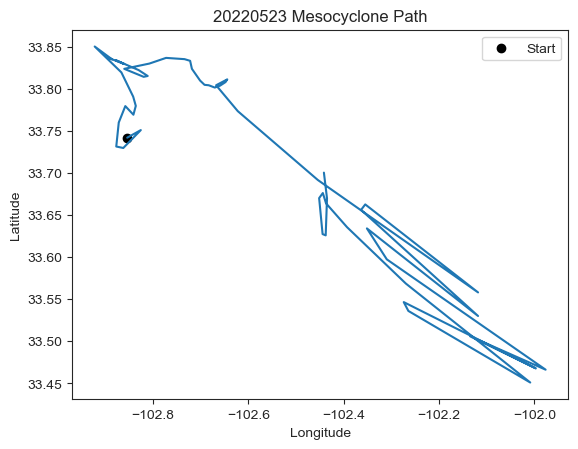

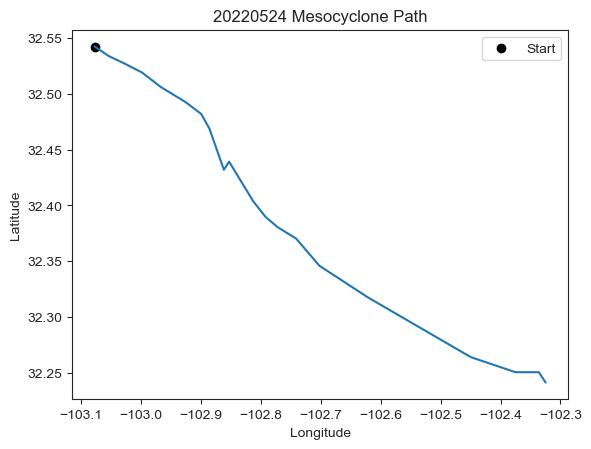

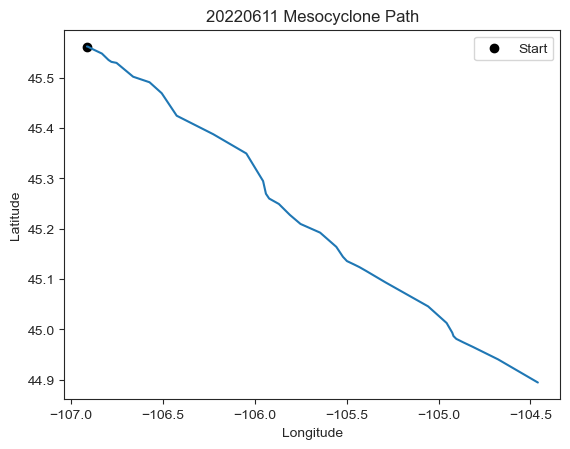

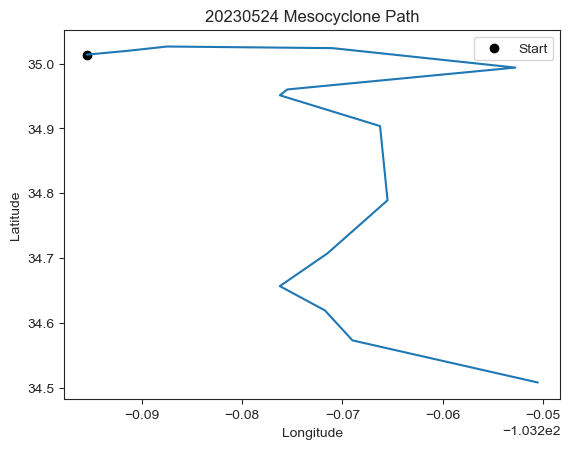

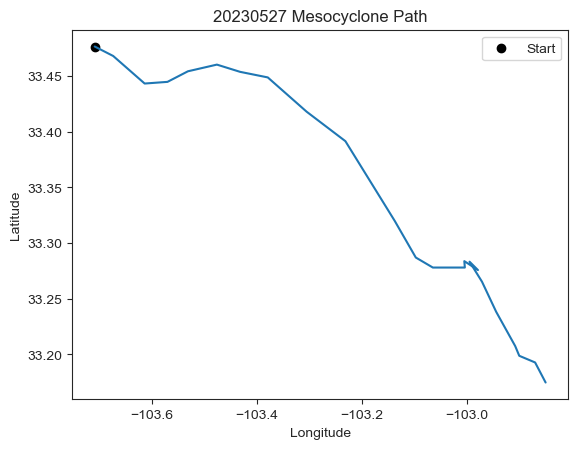

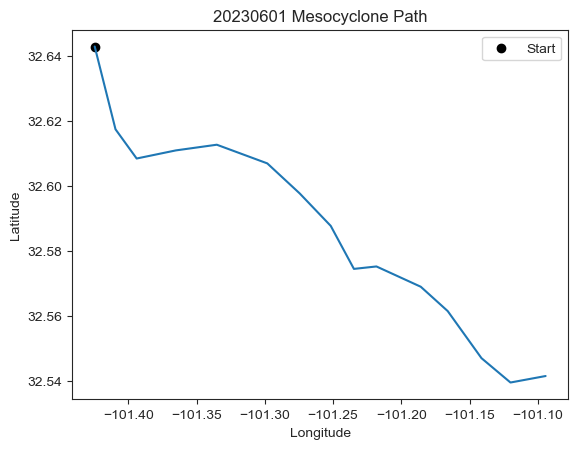

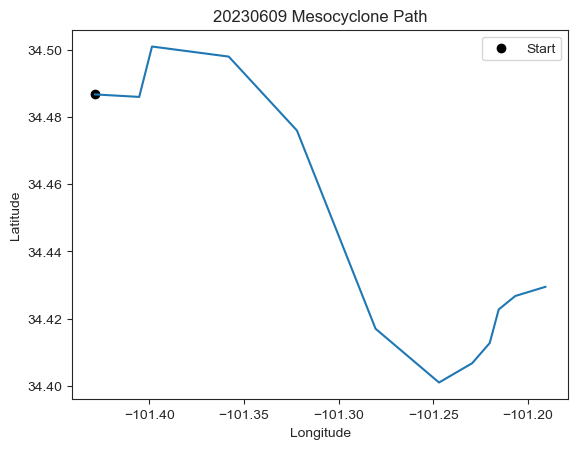

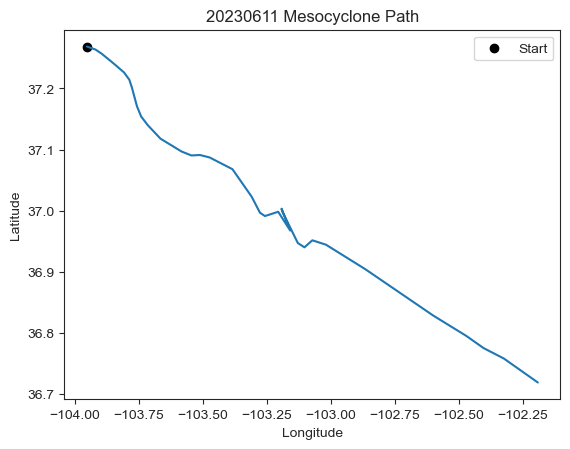

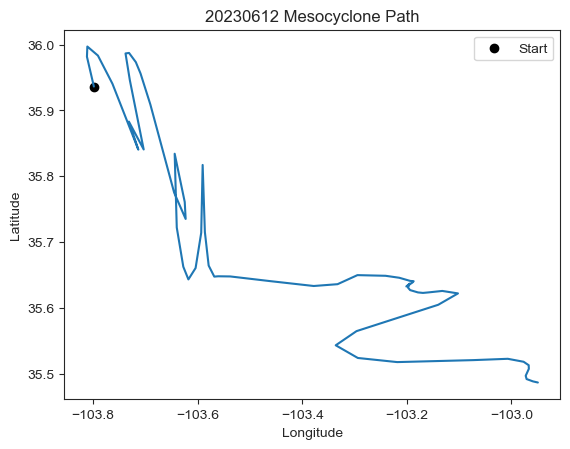

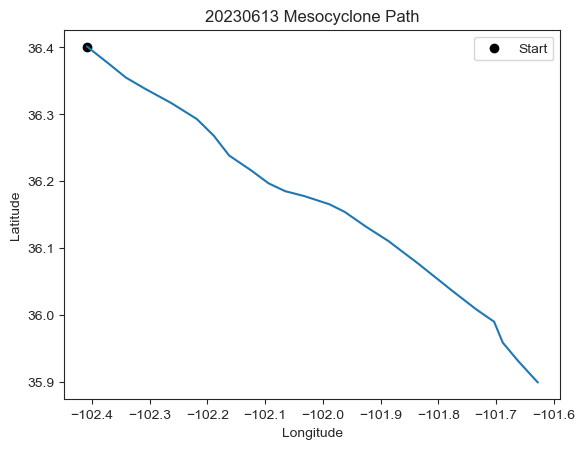

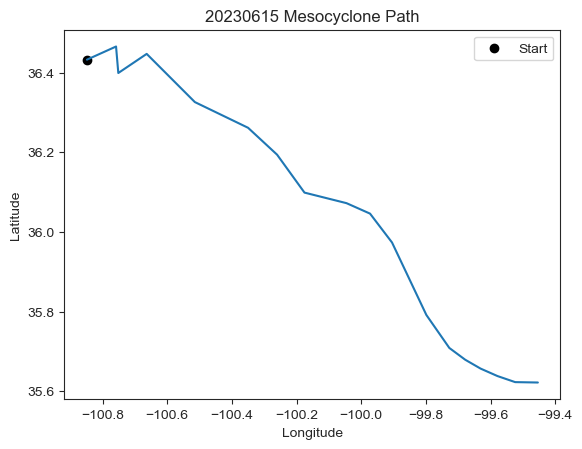

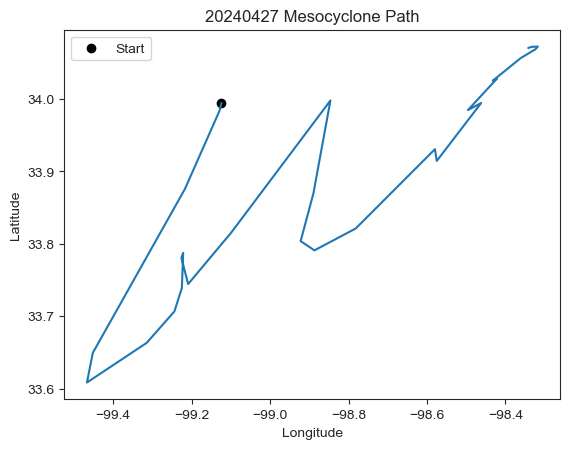

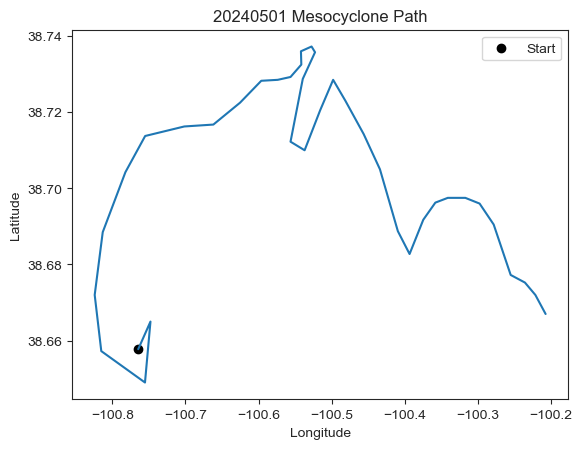

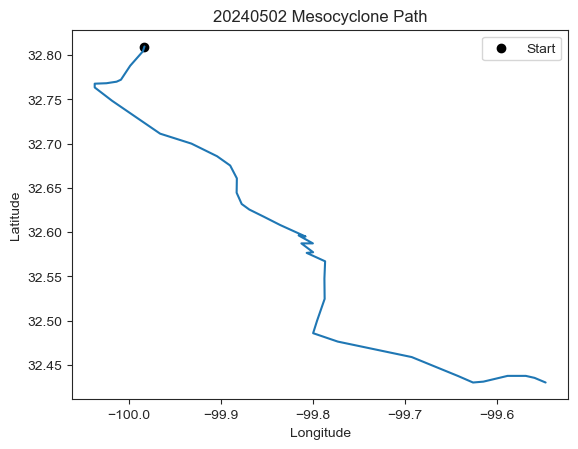

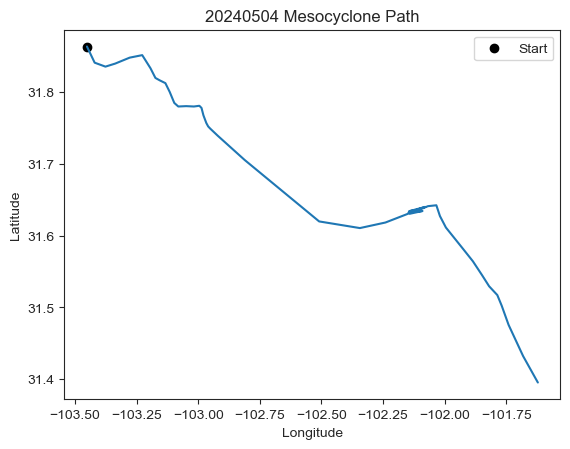

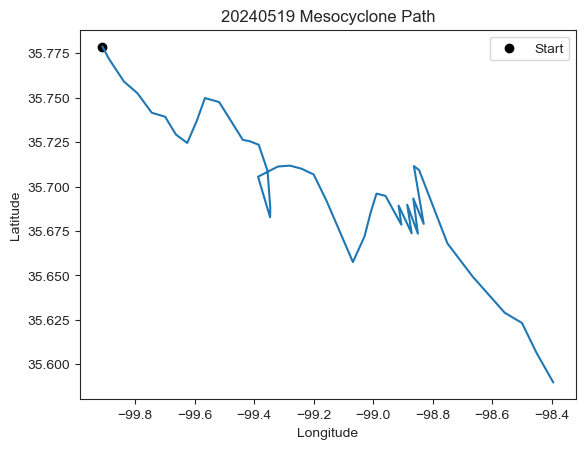

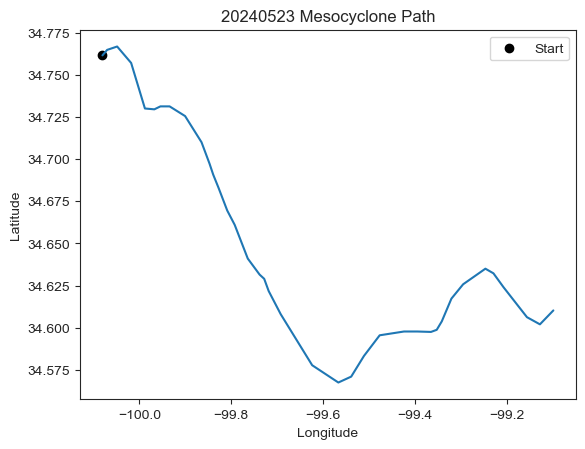

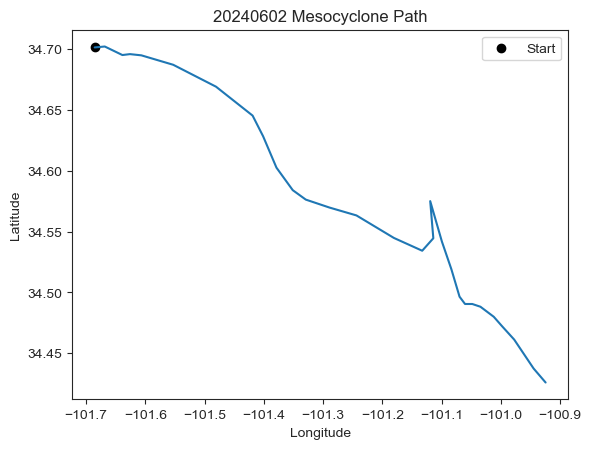

In [56]:
for d in meso_ids_dict:
    date_select = meso_location[meso_location['Date'] == d]
    plt.figure()
    plt.plot(date_select['Meso_Lon'], date_select['Meso_Lat'])
    plt.title(f'{d} Mesocyclone Path')
    plt.scatter(date_select['Meso_Lon'].iloc[0], date_select['Meso_Lat'].iloc[0], label='Start', marker='o', color='k')
    plt.legend()
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

In [57]:
meso_location[meso_location['Date'] == '20220524'].loc[70]

Meso_Lat                32.3175
Meso_Lon            -102.621001
Date                   20220524
Time        2022-05-24 21:24:15
Name: 70, dtype: object

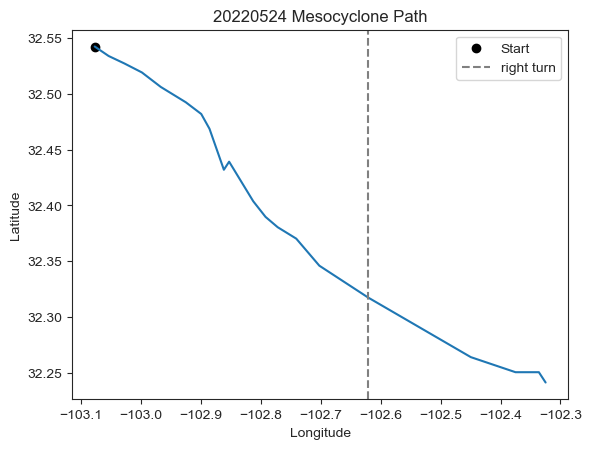

In [58]:
date_select = meso_location[meso_location['Date'] == '20220524']
plt.figure()
plt.plot(date_select['Meso_Lon'], date_select['Meso_Lat'])
plt.title('20220524 Mesocyclone Path')
plt.scatter(date_select['Meso_Lon'].iloc[0], date_select['Meso_Lat'].iloc[0], label='Start', marker='o', color='k')
plt.axvline(date_select.loc[70]['Meso_Lon'], linestyle='--', color='gray', label='right turn')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

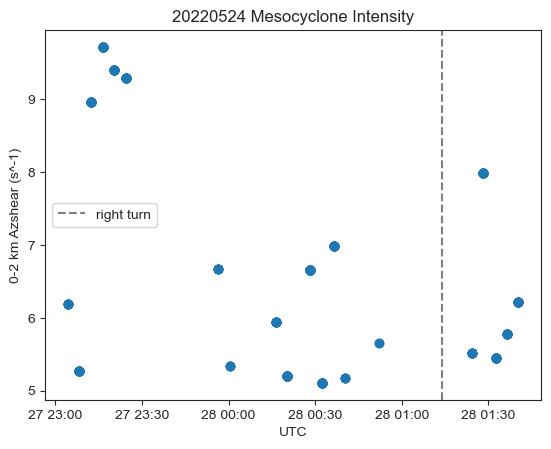

In [59]:
date_select = meso_azshear_df[meso_azshear_df['Date'] == '20230527']
rt_time = pd.Timestamp('2023-05-28 01:14:00')
plt.figure()
plt.scatter(date_select['Time'], date_select['Meso_Max'])
plt.title('20220524 Mesocyclone Intensity')
plt.axvline(rt_time, linestyle='--', color='gray', label='right turn')
plt.legend()
plt.xlabel('UTC')
plt.ylabel('0-2 km Azshear (s^-1)')
plt.show()

# Test Cases

In [11]:
df_copy = df_all_new.copy()
df_copy['Datetime Int'] = pd.to_datetime(df_all_new['Datetime'])

In [12]:
df_copy['NF or FF'] = np.where(df_copy['Distance'] <= 30, 'nf', 'ff')

In [13]:
def right_turn_time(date, date_utc):
    
    test_case4 = df_copy[(df_copy['Date'] == date)]
    rt_time = pd.Timestamp(date_utc)
    
    test_case4['Right Turn'] = np.where(test_case4['Datetime Int'] < rt_time,
                                       'before',
                                       'after'
                                      )
    return test_case4

In [14]:
def normalize_rt_time(test_case2, rt_time):
    test_case2['dt_rt'] = test_case2['Datetime Int'] - rt_time
    test_case2['dt_rt (min)'] = ((test_case2['Datetime Int'] - rt_time).dt.total_seconds() / 60).astype(float)

In [15]:
def rt_time_groups(test_case2, x):
    
    group1 = np.nanmean(test_case2[(test_case2['dt_rt (min)'] > -61) & (test_case2['dt_rt (min)'] < -44)][x], axis=0)
    group2 = np.nanmean(test_case2[(test_case2['dt_rt (min)'] > -46) & (test_case2['dt_rt (min)'] < -29)][x], axis=0)
    group3 = np.nanmean(test_case2[(test_case2['dt_rt (min)'] > -31) & (test_case2['dt_rt (min)'] < -14)][x], axis=0)
    group4 = np.nanmean(test_case2[(test_case2['dt_rt (min)'] > -16) & (test_case2['dt_rt (min)'] < 1)][x], axis=0)

    return group1, group2, group3, group4

In [16]:
def composite_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0)
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [17]:
def calc_srh_for_heights(test_case2):
    
    srh_2km = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:196], test_case2[test_case2['u or v'] == 'v'].iloc[i,:196])
            for i in range(len(test_case2[test_case2['u or v'] == 'u']))]

    srh_1km = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:100], test_case2[test_case2['u or v'] == 'v'].iloc[i,:100])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]
    
    srh_500m = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:50], test_case2[test_case2['u or v'] == 'v'].iloc[i,:50])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]

    srh_250m = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:25], test_case2[test_case2['u or v'] == 'v'].iloc[i,:25])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]

    srh_100m = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:10], test_case2[test_case2['u or v'] == 'v'].iloc[i,:10])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]

    return srh_2km, srh_1km, srh_500m, srh_250m, srh_100m

In [18]:
def calc_srw_for_heights(test_case2):

    u = test_case2[test_case2['u or v'] == 'u']
    v = test_case2[test_case2['u or v'] == 'v']
    
    srh_2km = comp_srw(u,v, 194)

    srh_1km = comp_srw(u,v, 100)
    
    srh_500m = comp_srw(u,v, 50)

    srh_250m = comp_srw(u,v, 25)

    srh_100m = comp_srw(u,v, 10)

    return srh_2km, srh_1km, srh_500m, srh_250m, srh_100m

In [19]:
def name_columns(test_case2, variable, srh_2km, srh_1km, srh_500m, srh_250m, srh_100m):
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}02km'] = srh_2km
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}02km'] = srh_2km
    
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}01km'] = srh_1km
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}01km'] = srh_1km
    
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}0500m'] = srh_500m
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}0500m'] = srh_500m

    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}0250m'] = srh_250m
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}0250m'] = srh_250m
    
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}0100m'] = srh_100m
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}0100m'] = srh_100m

In [20]:
rt_time_dict = {
    
    '20220523': pd.Timestamp('2022-05-23 23:40:00'),
    '20220524': pd.Timestamp('2022-05-24 21:36:20'),
    '20230524': pd.Timestamp('2023-05-24 23:00:00'),
    '20230527': pd.Timestamp('2023-05-28 00:26:00'),
    '20230611': pd.Timestamp('2023-06-11 20:50:00'),
    '20230612': pd.Timestamp('2023-06-12 22:24:00'),
    '20230613': pd.Timestamp('2023-06-13 19:30:00'),
    '20230615': pd.Timestamp('2023-06-15 23:45:00'),
    '20240427': pd.Timestamp('2024-04-27 19:30:00'),
    '20240501': pd.Timestamp('2024-05-02 00:40:00'),
    '20240602': pd.Timestamp('2024-06-03 00:40:00')
    
}

In [21]:
cases_df = pd.DataFrame()

for i in df_all_new['Date'].unique():
    print(i)
    rt_time = rt_time_dict[i] # get time

    test_case = right_turn_time(i, rt_time)
    srh_2km, srh_1km, srh_500m, srh_250m, srh_100m = calc_srh_for_heights(test_case)
    srw_2km, srw_1km, srw_500m, srw_250m, srw_100m = calc_srw_for_heights(test_case)
    name_columns(test_case, 'SRH', srh_2km, srh_1km, srh_500m, srh_250m, srh_100m)
    name_columns(test_case, 'SRW', srw_2km, srw_1km, srw_500m, srw_250m, srw_100m)
    normalize_rt_time(test_case, rt_time)
    g1, g2, g3, g4 = rt_time_groups(test_case, 'SRH01km')
    
    df = df_all_new[df_all_new['Date'] == i]
    test_case['Distance'] = df['Distance']

    cases_df = pd.concat([cases_df, test_case], ignore_index=True)

20220523
20220524
20230524
20230527
20230611
20230612
20230613
20230615
20240427
20240501
20240602


In [22]:
def plot_stuff(test_case2, date, rt_time, srw_srh):
    plt.figure(figsize=(15,5))
    plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u'][f'{srw_srh}02km'], label='0-2 km', alpha=0.5)
    plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u'][f'{srw_srh}01km'], label='0-1 km', color='orange', alpha=0.5)
    plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u'][f'{srw_srh}0500m'], color='red', label='0-500 m', alpha=0.5)
    plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u'][f'{srw_srh}0100m'], color='green', label='0-100 m', alpha=0.5)
    plt.xlabel('Datetime (UTC)')
    plt.ylabel(f'{srw_srh}')
    plt.axvline(rt_time, linestyle='--', color='black', label='Right Turn')
    #plt.legend()
    plt.title(f'{srw_srh} Over Time {date}')
    #plt.show()

In [23]:
cases_df['Time From Tor (min)'] = df_all_new['Time From Tor (min)']

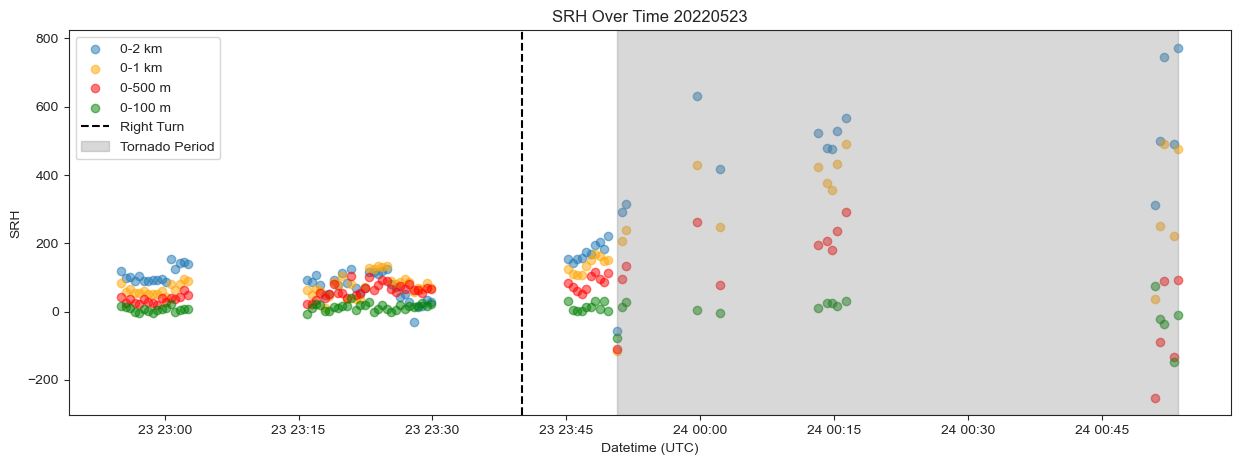

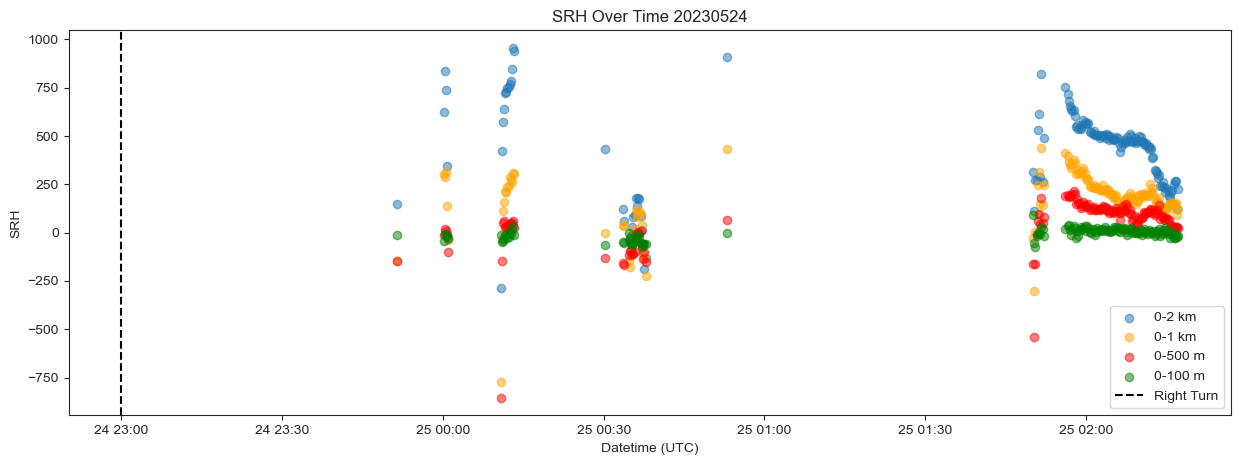

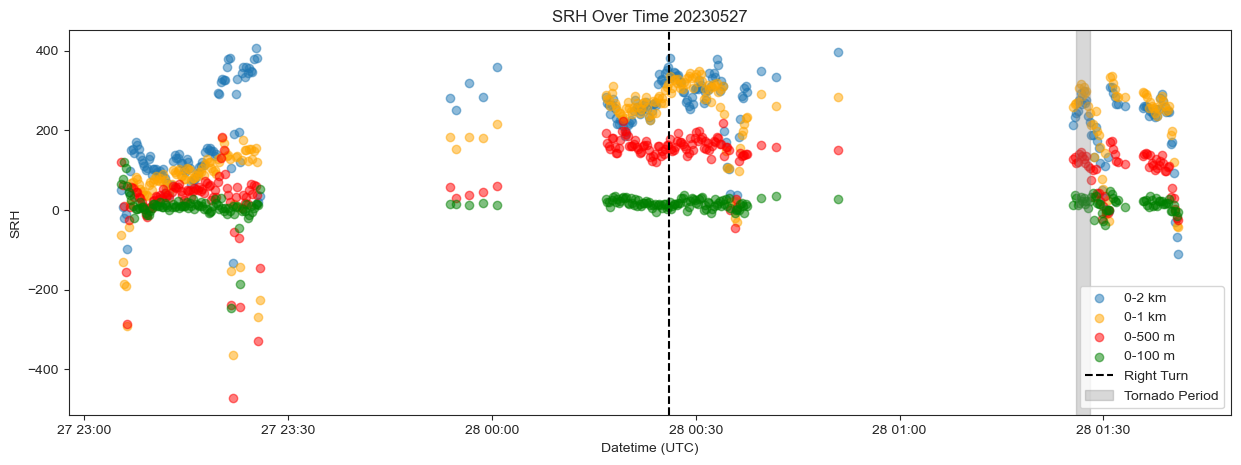

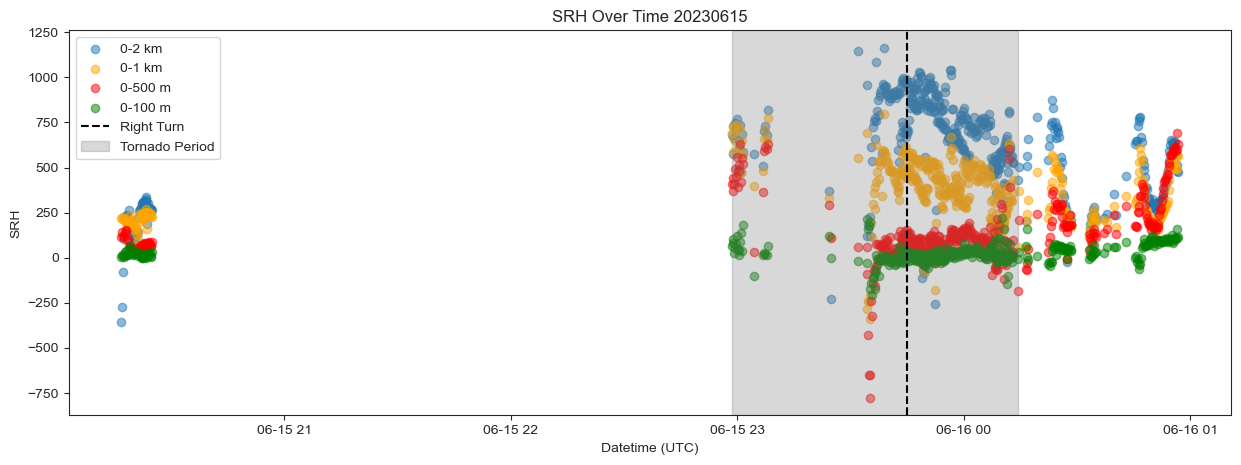

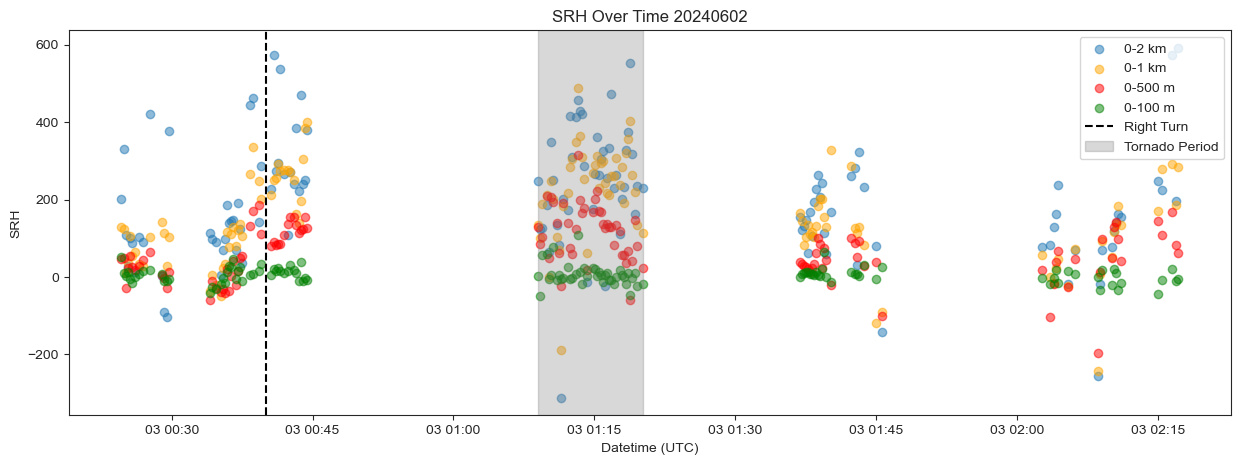

In [61]:
for i in df_all_new['Date'].unique():

    table = cases_df[cases_df['Date'] == i]
    rt_time = rt_time_dict[i]

    if rt_time is None:
        continue

    if table['Tor or Nontor'].iloc[0] == 'tor':

        tor_time = table.loc[
            table['Time From Tor (min)'] == 0,
            'Datetime'
        ]
        
        plot_stuff(table, i, rt_time, 'SRH')
        
        if not tor_time.empty:
            tor_time_start = tor_time.iloc[0]
            tor_time_end = tor_time.iloc[-1]
            plt.axvspan(tor_time_start, tor_time_end, color='gray', alpha=0.3, label='Tornado Period')


        plt.legend()
        plt.show()

    #plot_stuff(table, i, rt_time, 'SRH')

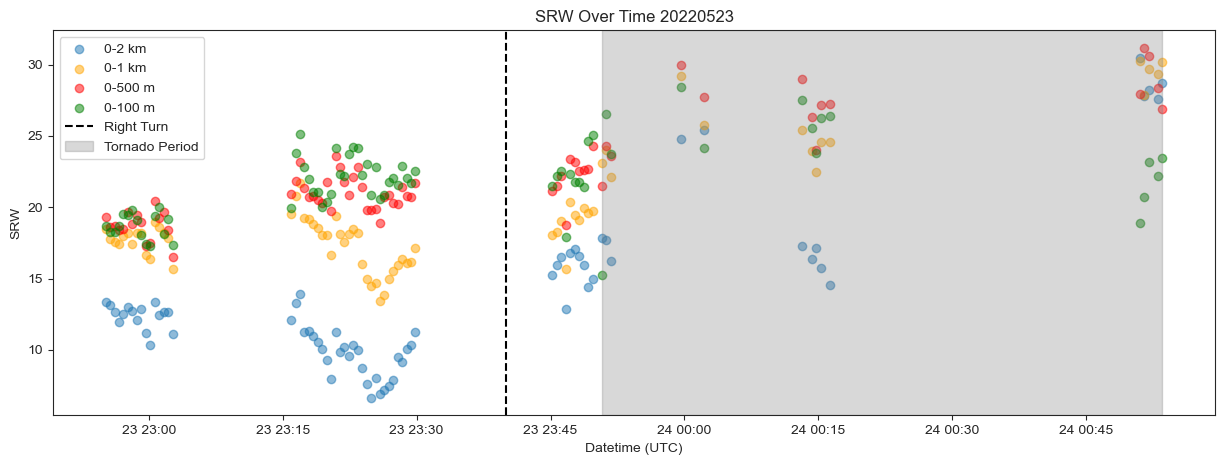

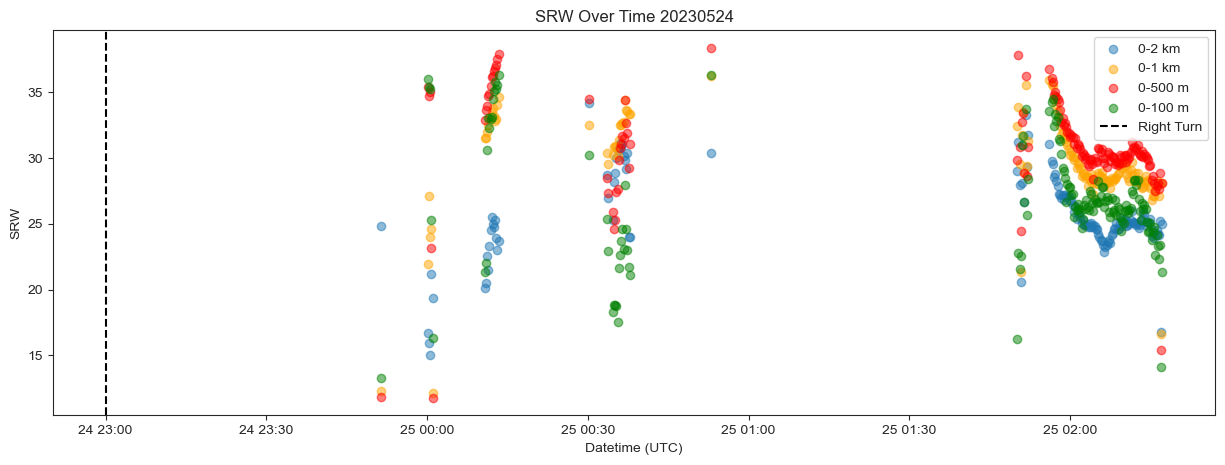

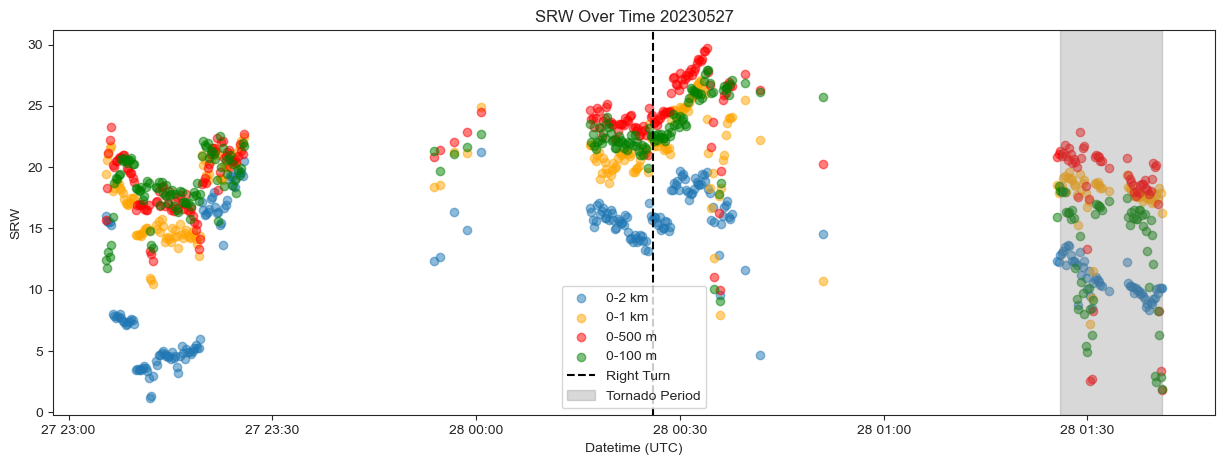

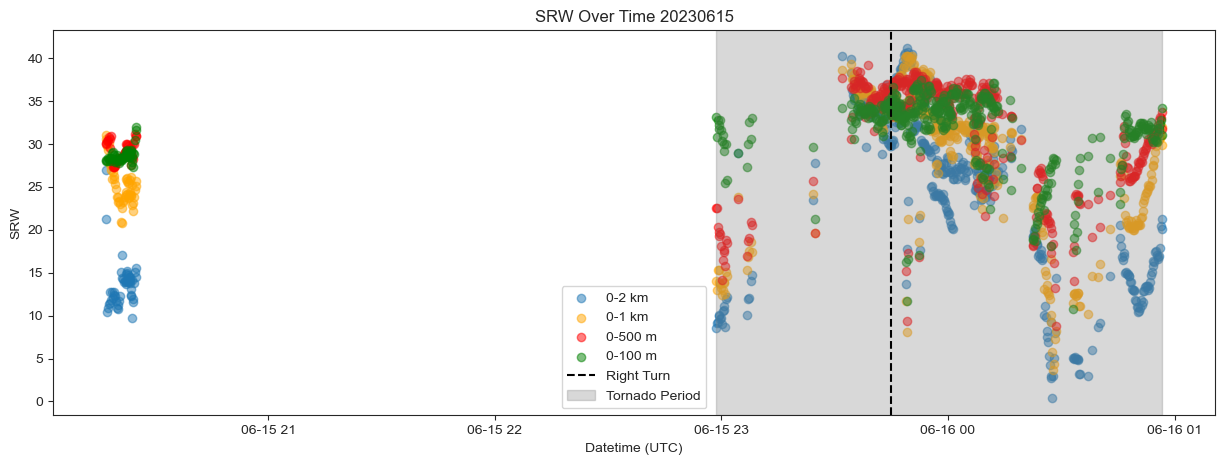

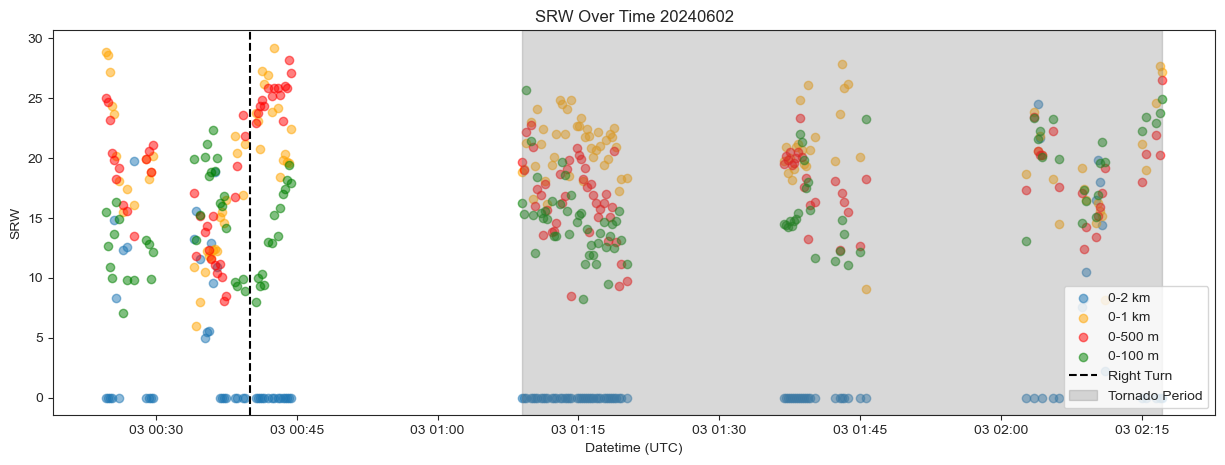

In [25]:
for i in df_all_new['Date'].unique():

    table = cases_df[cases_df['Date'] == i]
    rt_time = rt_time_dict[i]

    if rt_time is None:
        continue

    if table['Tor or Nontor'].iloc[0] == 'tor':

        tor_time = table.loc[
            table['Time From Tor (min)'] == 0,
            'Datetime'
        ]
        
        plot_stuff(table, i, rt_time, 'SRW')
        
        if not tor_time.empty:
            tor_time = tor_time.iloc[0]
            plt.axvspan(tor_time, table['Datetime'].max(), color='gray', alpha=0.3, label='Tornado Period')


        plt.legend()
        plt.show()

In [ ]:
for i in df_all_new['Date'].unique():

    table = cases_df[cases_df['Date'] == i]
    rt_time = rt_time_dict[i]

    if rt_time == None:
        continue
    
    plot_stuff(table, i, rt_time, 'SRW')

Test for Normal distribution so we can do stats for statistical significance

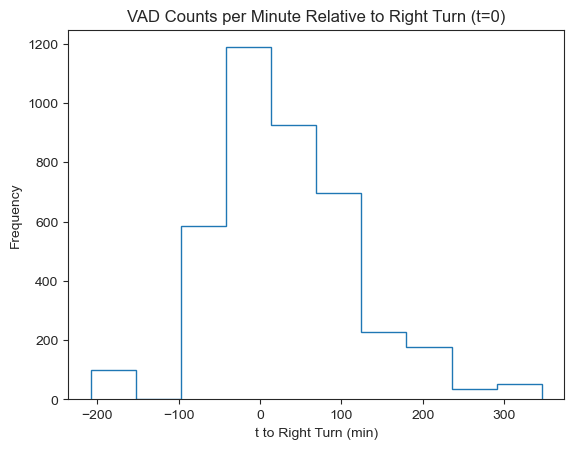

In [26]:
counts, bins = np.histogram(cases_df['dt_rt (min)'])
plt.stairs(counts, bins)
plt.title('VAD Counts per Minute Relative to Right Turn (t=0)')
plt.xlabel('t to Right Turn (min)')
plt.ylabel('Frequency')
plt.show()

In [28]:
from sklearn.linear_model import LinearRegression

In [ ]:
cases_df_tor = cases_df[cases_df['Tor or Nontor'] == 'tor']
cases_df_nontor = cases_df[cases_df['Tor or Nontor'] == 'nontor']
model = LinearRegression()
model.fit(np.array(cases_df_tor['SRH01km']).reshape(-1, 1), np.array(cases_df_tor['dt_rt (min)']).reshape(-1,1))

In [ ]:
model.fit(np.array(cases_df_nontor['SRH01km']).reshape(-1, 1), np.array(cases_df_nontor['dt_rt (min)']).reshape(-1,1))

In [29]:
cases_df_tor_srh = cases_df_tor.filter(regex='^SRH')
cases_df_tor_srw = cases_df_tor.filter(regex='^SRW')

cases_df_nontor_srh = cases_df_nontor.filter(regex='^SRH')
cases_df_nontor_srw = cases_df_nontor.filter(regex='^SRW')

In [30]:
cases_df_tor_srh['Date'] = cases_df_tor['Date']
cases_df_tor_srw['Date'] = cases_df_tor['Date']
cases_df_tor_srh['dt_rt (min)'] = cases_df_tor['dt_rt (min)']
cases_df_tor_srw['dt_rt (min)'] = cases_df_tor['dt_rt (min)']

cases_df_nontor_srh['Date'] = cases_df_nontor['Date']
cases_df_nontor_srw['Date'] = cases_df_nontor['Date']
cases_df_nontor_srh['dt_rt (min)'] = cases_df_nontor['dt_rt (min)']
cases_df_nontor_srw['dt_rt (min)'] = cases_df_nontor['dt_rt (min)']

In [31]:
import scipy.stats

In [69]:
cases_df_tor_srh

,SRH02km,SRH01km,SRH0500m,SRH0250m,SRH0100m,Date,dt_rt (min)
0,119.748598,85.210929,43.718735,37.812320,17.004567,20220523,-44.833333
1,98.612390,56.614540,25.731828,14.998987,13.887116,20220523,-44.333333
2,100.986069,65.449991,36.041791,15.922256,10.313456,20220523,-43.833333
3,90.521531,55.650706,24.762802,5.096974,0.174697,20220523,-43.350000
4,104.417661,55.601731,23.261166,2.217713,-5.170683,20220523,-42.850000
...,...,...,...,...,...,...,...
3981,247.702443,171.659933,144.348704,6.895158,-42.710430,20240602,94.983333
3982,226.212812,279.491115,108.369836,-1.271206,-7.597013,20240602,95.416667
3983,573.646974,292.708004,169.162464,23.730554,20.732365,20240602,96.516667
3984,196.952959,187.312800,82.665650,-7.797507,-11.436844,20240602,96.950000


In [75]:
def linear_reg_tnt(cases_df_tor_srh, cases_df_tor_srw):
    records = []
    
    for d in cases_df_tor_srh['Date'].unique():
        df_srh = cases_df_tor_srh[cases_df_tor_srh['Date'] == d]
        df_srw = cases_df_tor_srw[cases_df_tor_srw['Date'] == d]

        # SRH
        for col in cases_df_tor_srh.columns[:-2]:
            r, p = scipy.stats.pearsonr(
                df_srh[col],
                df_srh['dt_rt (min)']
            )

            records.append({
                'Date': d,
                'Variable': col,
                'Type': 'SRH',
                'r': r,
                'p': p
            })

        # SRW
        for col in cases_df_tor_srw.columns[:-2]:
            r, p = scipy.stats.pearsonr(
                df_srw[col],
                df_srw['dt_rt (min)']
            )

            records.append({
                'Date': d,
                'Variable': col,
                'Type': 'SRW',
                'r': r,
                'p': p
            })

    return pd.DataFrame(records)

In [131]:
linear_reg_df_tor = linear_reg_tnt(cases_df_tor_srh[cases_df_tor_srh['dt_rt (min)'] <0], cases_df_tor_srw[cases_df_tor_srw['dt_rt (min)'] <0])
linear_reg_df_tor_post = linear_reg_tnt(cases_df_tor_srh[cases_df_tor_srh['dt_rt (min)'] >0], cases_df_tor_srw[cases_df_tor_srw['dt_rt (min)'] >0])

In [130]:
linear_reg_df_nontor = linear_reg_tnt(cases_df_nontor_srh[cases_df_nontor_srh['dt_rt (min)'] <0], cases_df_nontor_srw[cases_df_nontor_srw['dt_rt (min)'] <0])
linear_reg_df_nontor_post = linear_reg_tnt(cases_df_nontor_srh[cases_df_nontor_srh['dt_rt (min)'] >0], cases_df_nontor_srw[cases_df_nontor_srw['dt_rt (min)'] >0])

In [85]:
linear_reg_df_tor.sort_values(by='r', ascending=False)

,Date,Variable,Type,r,p
7,20220523,SRW0500m,SRW,0.880834,1.175051e-46
6,20220523,SRW01km,SRW,0.793675,1.387346e-31
0,20220523,SRH02km,SRH,0.793297,1.551960e-31
5,20220523,SRW02km,SRW,0.784178,2.171564e-30
8,20220523,SRW0250m,SRW,0.719162,1.418472e-23
1,20220523,SRH01km,SRH,0.708383,1.254253e-22
13,20230524,SRH0250m,SRH,0.564179,2.874776e-25
21,20230527,SRH01km,SRH,0.549017,3.559602e-41
12,20230524,SRH0500m,SRH,0.526480,1.186553e-21
14,20230524,SRH0100m,SRH,0.523487,2.199526e-21


In [139]:
def r_boxplot_per_iop(linear_reg_df_tor, x, y, hue, palette, before_after):
    
    sns.boxplot(
        data=linear_reg_df_tor,
        x=x,
        y=y,
        hue=hue,
        palette=palette
    )
    
    plt.axhline(0, color='black', linestyle='--')
    plt.xticks(rotation=70)
    plt.ylabel('Pearson r')
    plt.title(f'Pearson r per IOP {before_after} rt')

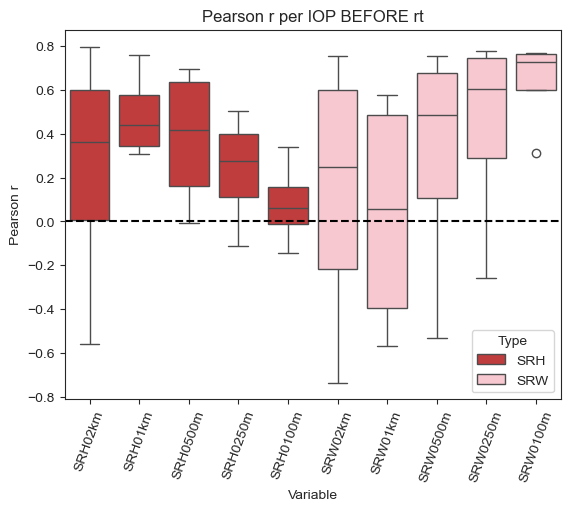

In [141]:
r_boxplot_per_iop(linear_reg_df_tor, 'Variable', 'r', 'Type', ['tab:red', 'pink'], 'BEFORE')

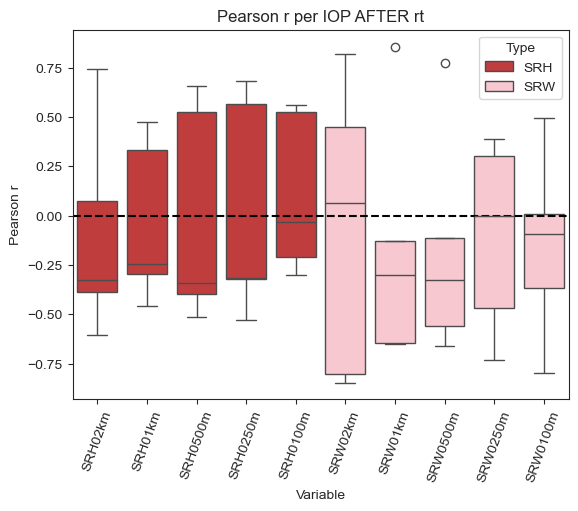

In [142]:
r_boxplot_per_iop(linear_reg_df_tor_post, 'Variable', 'r', 'Type', ['tab:red', 'pink'], 'AFTER')

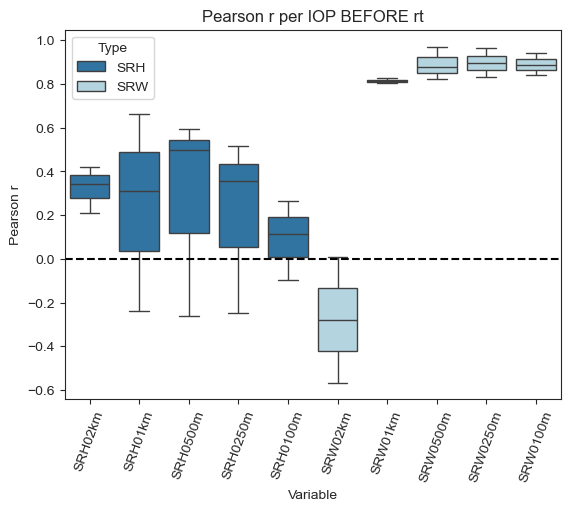

In [143]:
r_boxplot_per_iop(linear_reg_df_nontor, 'Variable', 'r', 'Type', ['tab:blue', 'lightblue'], 'BEFORE')

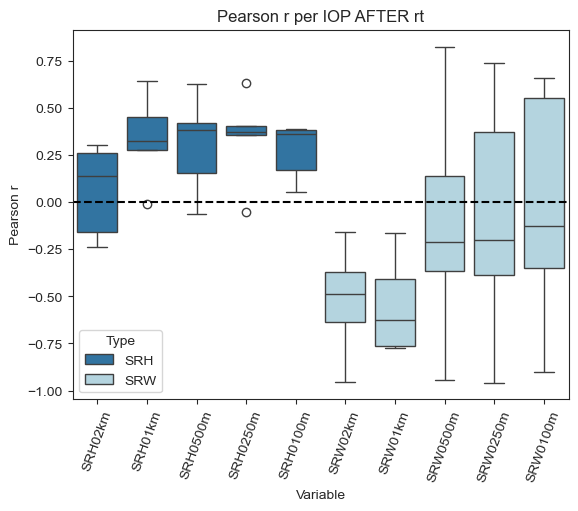

In [144]:
r_boxplot_per_iop(linear_reg_df_nontor_post, 'Variable', 'r', 'Type', ['tab:blue', 'lightblue'], 'AFTER')

**REMEMBER**: A SIGNIFICANT P VALUE ONLY MEANS THAT THE LINEAR RELATIONSHIP IS NOT DUE TO CHANCE, NOT THE STRENGTH OF THE RELATIONSHIP OR PROVE CAUSATION!!!! (the null hypothesis is that r=0, with the alternate hypothesis meaning r =/= 0)

In [110]:
# Thanks to Chatty for making my separate figures subplots and coloring the distance dots

import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

def pretty_lin_reg(cases_df, prior_or_post, variable):
    
    if prior_or_post == 'prior':
        prior_only = cases_df[cases_df['dt_rt (min)'] < 0]
        label = 'Before'
        suptitle = f'Pre RT (t < 0) {variable}'
    else:
        prior_only = cases_df[cases_df['dt_rt (min)'] > 0]
        label='After'
        suptitle = f'Post RT (t > 0) {variable}'
    
    # Split dates into tornadic and nontornadic
    tor_dates = []
    nontor_dates = []
    
    for i in prior_only['Date'].unique():
        table = prior_only[prior_only['Date'] == i]
        tnt = table['Tor or Nontor'].iloc[0]
    
        if tnt == 'tor':
            tor_dates.append(i)
        else:
            nontor_dates.append(i)
    
    # Number of rows needed
    nrows = max(len(tor_dates), len(nontor_dates))
    
    fig, axes = plt.subplots(
        nrows, 2,
        figsize=(12, 4 * nrows),
        squeeze=False
    )
    
    # ---------------------------------
    # Plot tornadic cases - LEFT
    # ---------------------------------
    for row, i in enumerate(tor_dates):
    
        table = prior_only[prior_only['Date'] == i].copy()
        ax = axes[row, 0]
    
        r, pvalue = scipy.stats.pearsonr(
            table[variable],
            table['dt_rt (min)']
        )
    
        norm = mpl.colors.Normalize(
            vmin=table['Distance'].min(),
            vmax=table['Distance'].max()
        )
    
        cmap = plt.cm.Reds_r
    
        scatter = ax.scatter(
            table['dt_rt (min)'],
            table[variable],
            c=table['Distance'],
            cmap=cmap,
            norm=norm,
            edgecolor='black',
            linewidth=0.5
        )
    
        sns.regplot(
            data=table,
            x='dt_rt (min)',
            y=variable,
            scatter=False,
            ax=ax,
            line_kws=dict(color='k')
        )
    
        ax.set_title(f'{i}')
        ax.annotate(
            f'R = {r:.2f}\np = {pvalue:.1e}',
            xy=(0.05, 0.95),
            xycoords='axes fraction',
            ha='left',
            va='top'
        )
    
        ax.set_xlabel(f'Time {label} Right Turn (min)')
        ax.set_ylabel(variable)
    
        # Colorbar
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label('Distance from Mesocyclone (km)')
    
    
    # ---------------------------------
    # Plot nontornadic cases - RIGHT
    # ---------------------------------
    for row, i in enumerate(nontor_dates):
    
        table = prior_only[prior_only['Date'] == i].copy()
        ax = axes[row, 1]
    
        r, pvalue = scipy.stats.pearsonr(
            table[variable],
            table['dt_rt (min)']
        )
    
        norm = mpl.colors.Normalize(
            vmin=table['Distance'].min(),
            vmax=table['Distance'].max()
        )
    
        cmap = plt.cm.Blues_r
    
        scatter = ax.scatter(
            table['dt_rt (min)'],
            table[variable],
            c=table['Distance'],
            cmap=cmap,
            norm=norm,
            edgecolor='black',
            linewidth=0.5
        )
    
        sns.regplot(
            data=table,
            x='dt_rt (min)',
            y=variable,
            scatter=False,
            ax=ax,
            line_kws=dict(color='k')
        )
    
        ax.set_title(f'{i}')
        ax.annotate(
            f'R = {r:.2f}\np = {pvalue:.1e}',
            xy=(0.05, 0.95),
            xycoords='axes fraction',
            ha='left',
            va='top'
        )
    
        ax.set_xlabel(f'Time {label} Right Turn (min)')
        ax.set_ylabel('variable')
    
        # Colorbar
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label('Distance from Mesocyclone (km)')
    
    
    # Remove unused subplots
    for row in range(len(tor_dates), nrows):
        fig.delaxes(axes[row, 0])
    
    for row in range(len(nontor_dates), nrows):
        fig.delaxes(axes[row, 1])
    
    
    # Column headers
    axes[0, 0].set_title('Tornadic', fontsize=16, fontweight='bold', pad=20)
    axes[0, 1].set_title('Nontornadic', fontsize=16, fontweight='bold', pad=20)
    
    plt.suptitle(suptitle, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

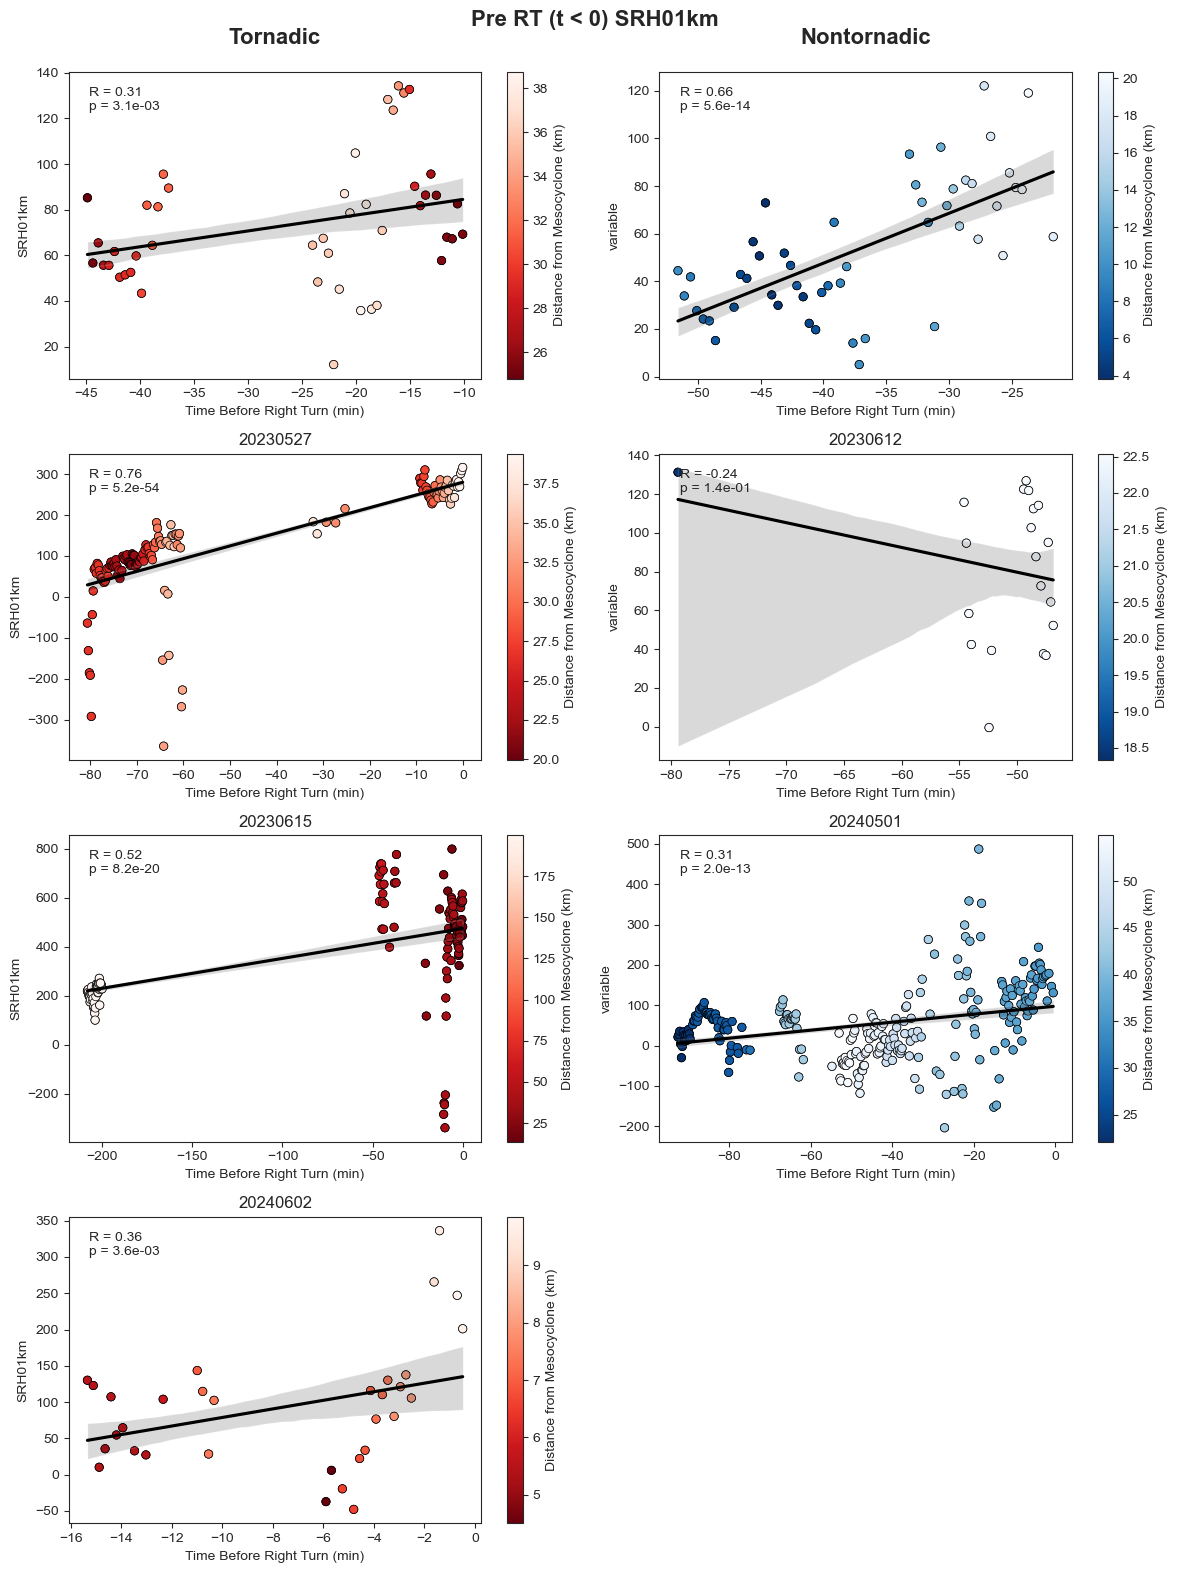

In [111]:
pretty_lin_reg(cases_df, 'prior', 'SRH01km')

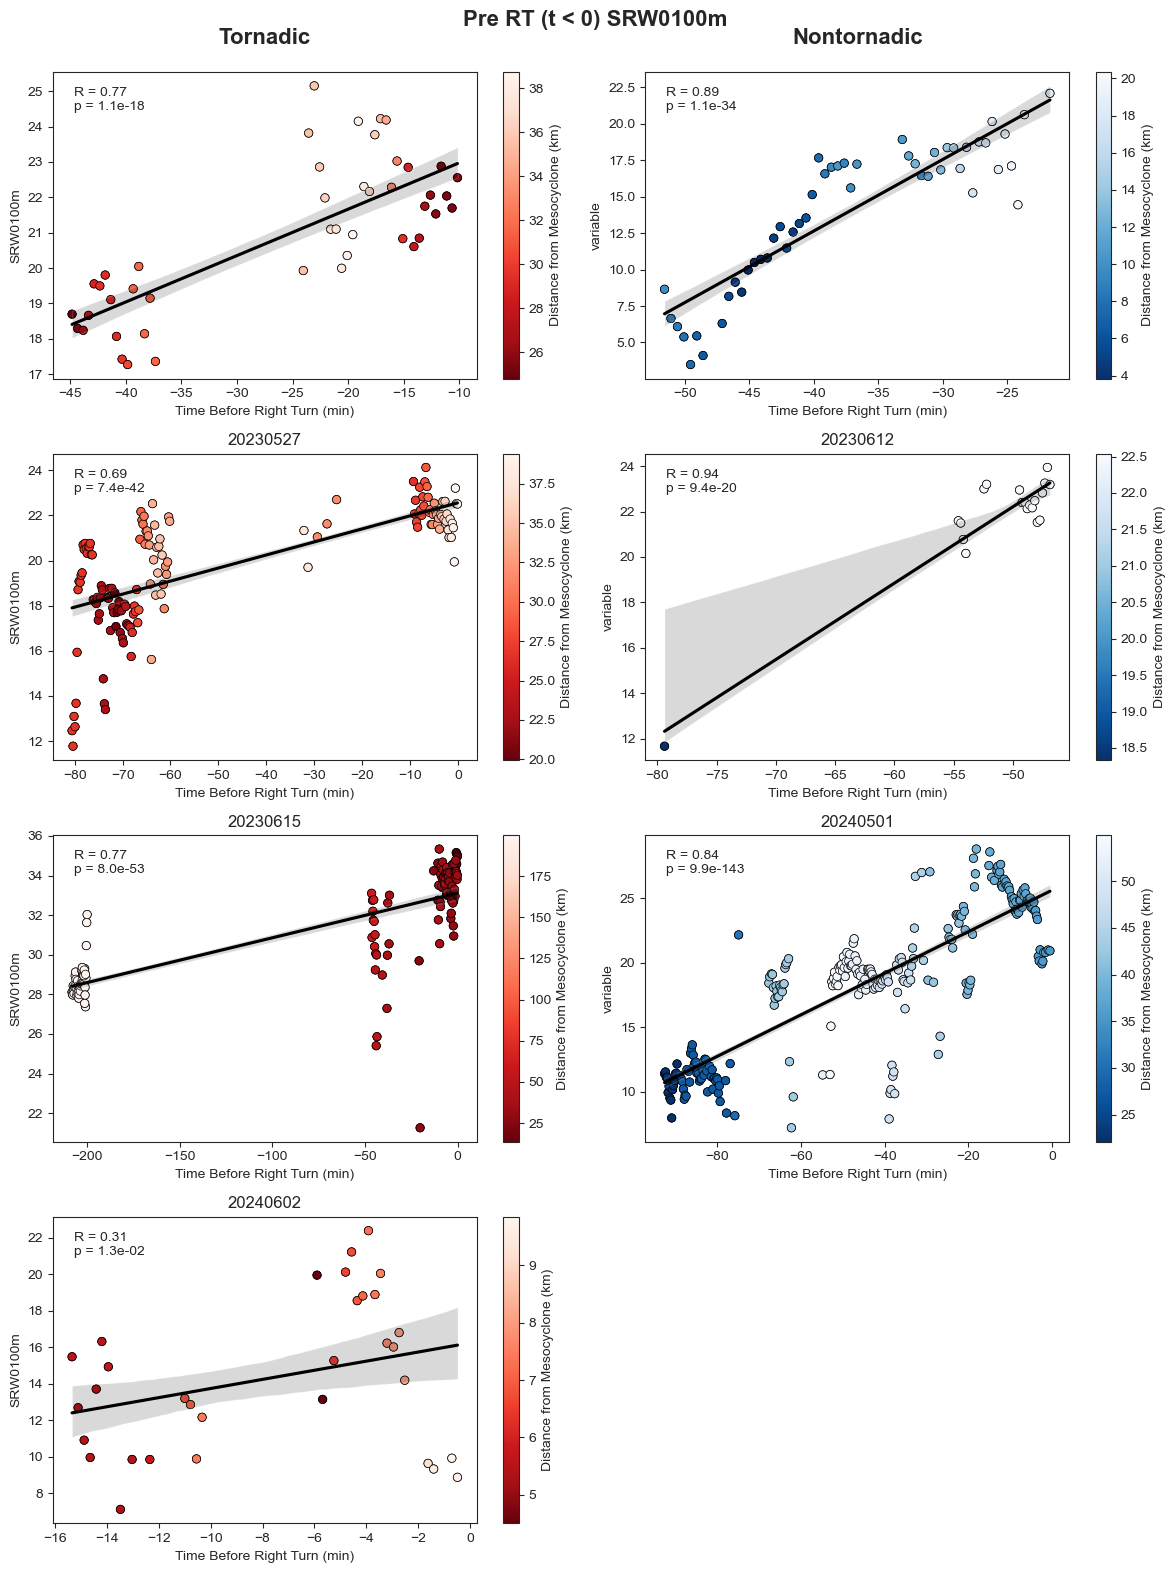

In [129]:
pretty_lin_reg(cases_df, 'prior', 'SRW0100m')

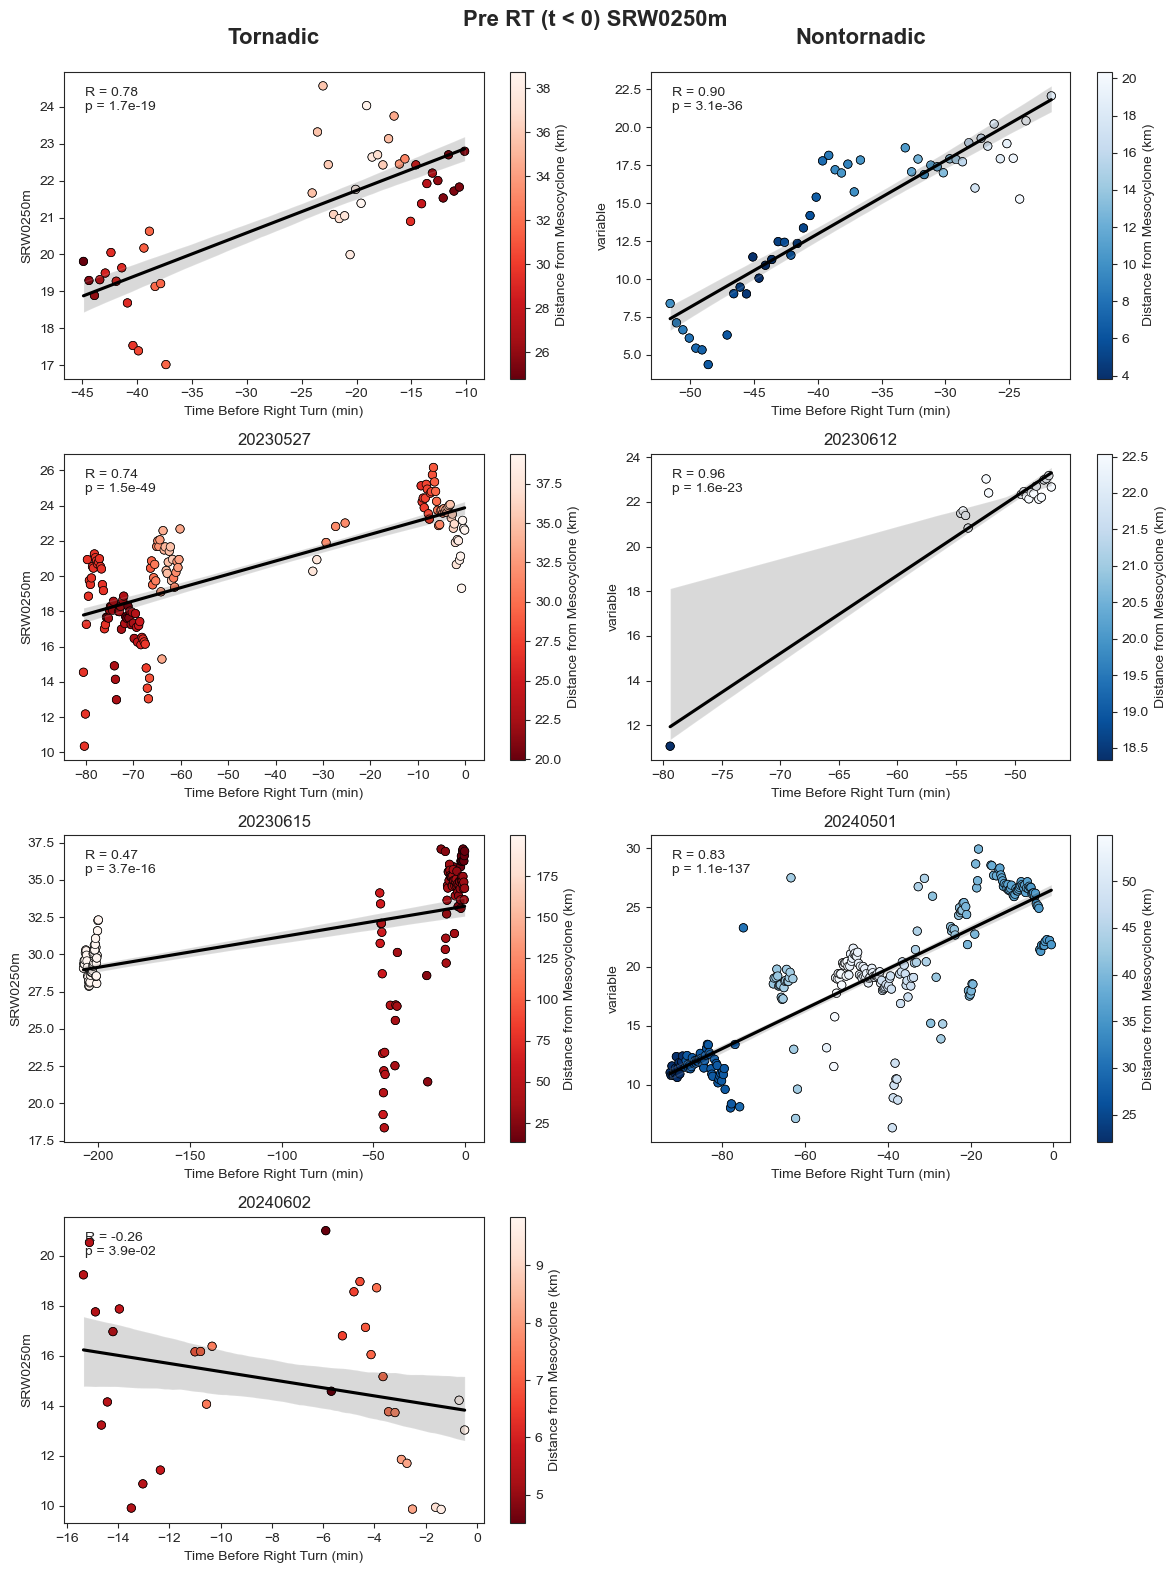

In [146]:
pretty_lin_reg(cases_df, 'prior', 'SRW0250m')

In [114]:
def stupid_plots_r(nrows, ncols, regex, suptitle):
                   
    n = len(linear_reg_df_tor.filter(regex='^r SRH').columns)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharex=True)
    axes = axes.flatten()
    
    for col, ax in zip(linear_reg_df_tor.filter(regex=regex).columns, axes):
        #ax.grid()
        ax.scatter(linear_reg_df_tor['Date'], linear_reg_df_tor[col], label='tor', color='orange')
        ax.scatter(linear_reg_df_nontor['Date'], linear_reg_df_nontor[col], label='nontor', color='tab:blue')
        ax.set_title(f'{col} per IOP')
        ax.legend()
        ax.axhline(0, color='gray', linestyle='--')
        for ax in axes[:n]:
            for label in ax.get_xticklabels():
                label.set_rotation(90)
                label.set_ha('right')

    for ax in axes.flat[len(axes):]:
        ax.set_visible(False)

    plt.suptitle(suptitle) 
    plt.tight_layout()
    plt.show()

In [116]:
linear_reg_df_tor

,Date,Variable,Type,r,p
0,20220523,SRH02km,SRH,-0.560648,9.098627e-09
1,20220523,SRH01km,SRH,0.308254,3.118431e-03
2,20220523,SRH0500m,SRH,0.695639,2.759641e-14
3,20220523,SRH0250m,SRH,0.506023,3.621836e-07
4,20220523,SRH0100m,SRH,0.341345,9.930002e-04
5,20220523,SRW02km,SRW,-0.735578,1.494437e-16
6,20220523,SRW01km,SRW,-0.337473,1.142829e-03
7,20220523,SRW0500m,SRW,0.652091,3.356038e-12
8,20220523,SRW0250m,SRW,0.778619,1.674364e-19
9,20220523,SRW0100m,SRW,0.767397,1.132105e-18


In [126]:
def stupid_plots_r(linear_reg_df_tor, linear_reg_df_nontor, nrows, ncols, srh_srw, suptitle):
    
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5*ncols, 4*nrows),
        sharex=True,
        sharey=True
    )
    
    axes = np.atleast_1d(axes).flatten()

    # Select SRH or SRW
    linear_reg_df_tor = linear_reg_df_tor[
        linear_reg_df_tor['Type'] == srh_srw
    ]
    
    linear_reg_df_nontor = linear_reg_df_nontor[
        linear_reg_df_nontor['Type'] == srh_srw
    ]

    # Get variables
    variables = linear_reg_df_tor['Variable'].unique()

    for col, ax in zip(variables, axes):

        # Get just this variable
        tor = linear_reg_df_tor[
            linear_reg_df_tor['Variable'] == col
        ]
        
        nontor = linear_reg_df_nontor[
            linear_reg_df_nontor['Variable'] == col
        ]

        # Plot r values
        ax.scatter(
            tor['Date'],
            tor['r'],
            label='Tor',
            color='orange'
        )
        
        ax.scatter(
            nontor['Date'],
            nontor['r'],
            label='Nontor',
            color='tab:blue'
        )

        ax.axhline(
            0,
            color='gray',
            linestyle='--'
        )

        ax.set_title(f'{col} per IOP')
        ax.set_ylabel('Pearson r')
        ax.tick_params(axis='x', rotation=90)
        ax.legend()

    # Hide unused axes
    for ax in axes[len(variables):]:
        ax.set_visible(False)

    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

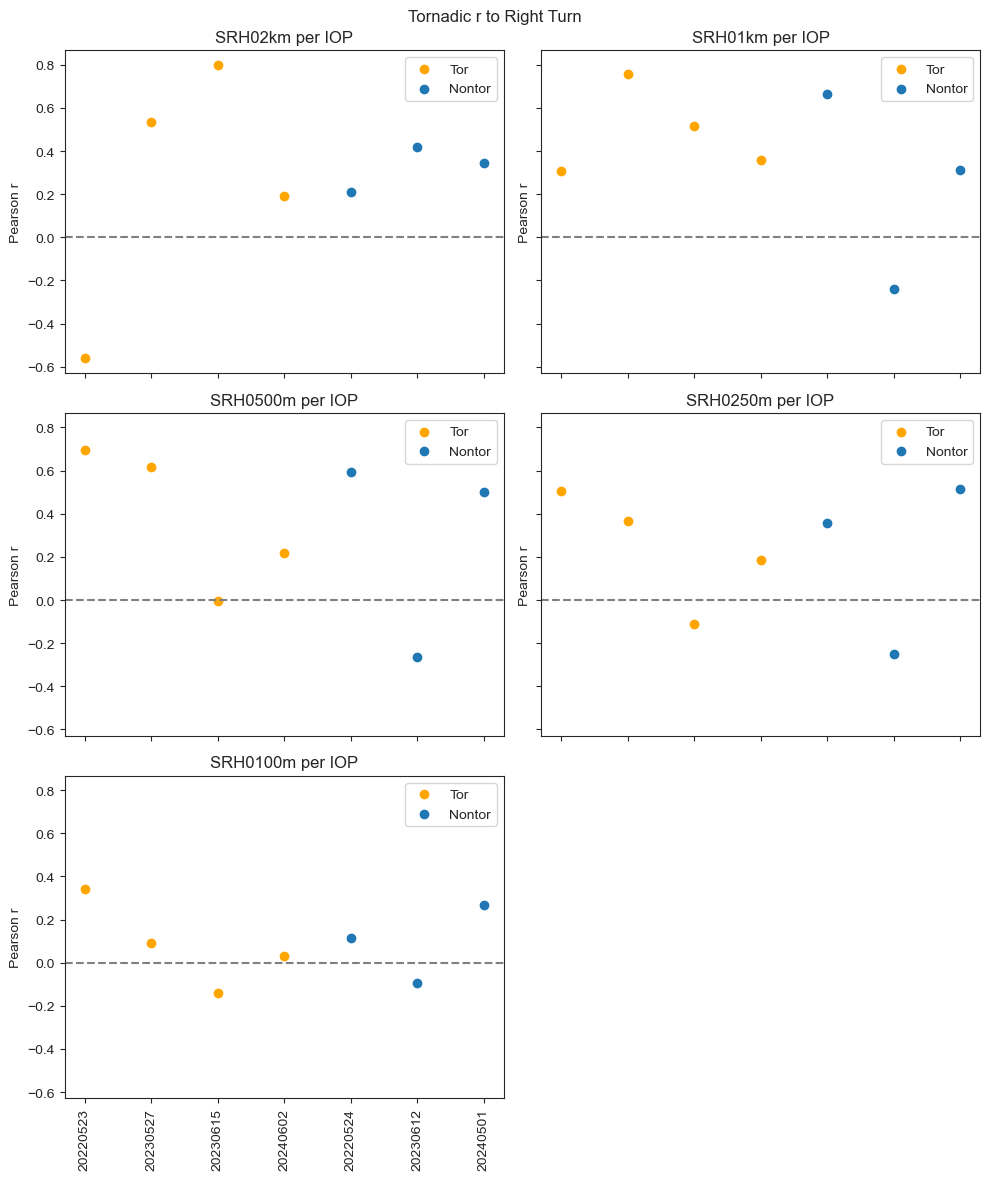

In [127]:
stupid_plots_r(linear_reg_df_tor, linear_reg_df_nontor, 3, 2, 'SRH', 'Tornadic r to Right Turn')

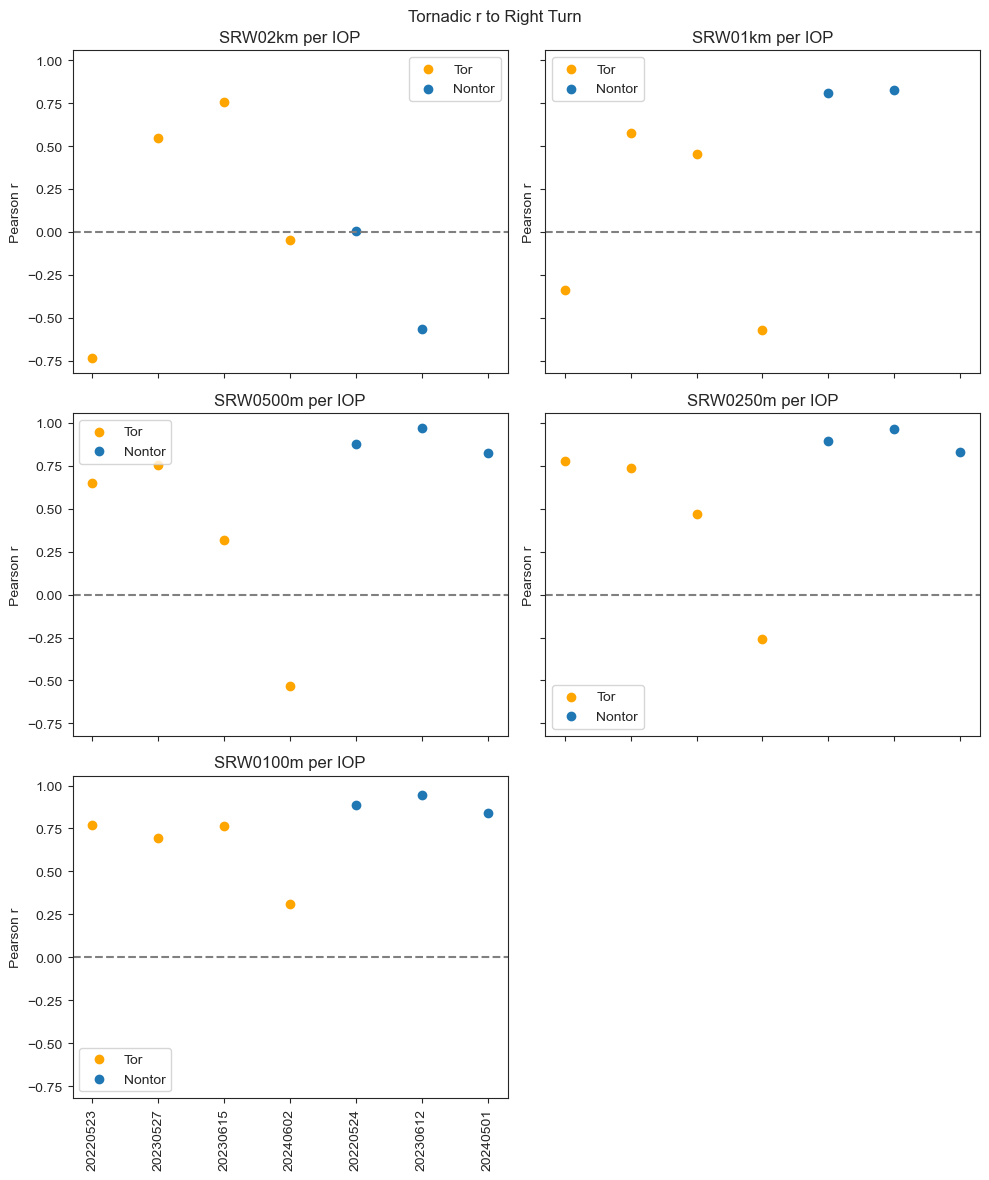

In [128]:
stupid_plots_r(linear_reg_df_tor, linear_reg_df_nontor, 3, 2, 'SRW', 'Tornadic r to Right Turn')

In [ ]:
# Julia original code
import scipy.stats
import seaborn as sns
import matplotlib as mpl

prior_only = cases_df[cases_df['dt_rt (min)'] < 0]

for i in prior_only['Date'].unique():
    table = prior_only[prior_only['Date'] == i]
    tnt = table['Tor or Nontor'].iloc[0]
    r, pvalue = scipy.stats.pearsonr(table['SRH01km'], table['dt_rt (min)'])

    plt.title(f'{i} SRH01km/Time BEFORE Right Turn Linear Fit {tnt}')
    if tnt == 'tor':
        ax = sns.regplot(data=table, x='dt_rt (min)', y='SRH01km', color='tab:red', line_kws=dict(color="k"))
    else:
        ax = sns.regplot(data=table, x='dt_rt (min)', y='SRH01km', color='tab:blue', line_kws=dict(color="k"))
        
    ax.annotate(f'R = {r:.2f}\np = {pvalue:.1e}', xy=(0.05, 0.95), xycoords='axes fraction',
            ha='left', va='top')
    plt.show()

# Hodographs

In [ ]:
def before_after_uv_avg(test_case2):
    before = test_case2[test_case2['Right Turn'] == 'before']
    after = test_case2[test_case2['Right Turn'] == 'after']
    
    before_avg_u = np.nanmean(before[before['u or v'] == 'u'].iloc[:, :196],axis=0)
    before_avg_v = np.nanmean(before[before['u or v'] == 'v'].iloc[:, :196],axis=0)
    
    after_avg_u = np.nanmean(after[after['u or v'] == 'u'].iloc[:, :196],axis=0)
    after_avg_v = np.nanmean(after[after['u or v'] == 'v'].iloc[:, :196],axis=0)

    return before_avg_u, before_avg_v, after_avg_u, after_avg_v

In [ ]:
def bef_af_nf_ff_avg(test_case2):
    profiles = (
        test_case2
        .groupby(['Right Turn', 'NF or FF', 'u or v'])
        .apply(lambda df: np.nanmean(df.iloc[:, :196], axis=0))
    )
    before_avg_u_nf = profiles[('before', 'nf', 'u')]
    before_avg_v_nf = profiles[('before', 'nf', 'v')]
    
    before_avg_u_ff = profiles[('before', 'ff', 'u')]
    before_avg_v_ff = profiles[('before', 'ff', 'v')]
    
    after_avg_u_nf = profiles[('after', 'nf', 'u')]
    after_avg_v_nf = profiles[('after', 'nf', 'v')]
    
    after_avg_u_ff = profiles[('after', 'ff', 'u')]
    after_avg_v_ff = profiles[('after', 'ff', 'v')]

    return before_avg_u_nf, before_avg_v_nf, before_avg_u_ff, before_avg_v_ff, after_avg_u_nf, after_avg_v_nf, after_avg_u_ff, after_avg_v_ff

In [ ]:
before_avg_u, before_avg_v, after_avg_u, after_avg_v = before_after_uv_avg(test_case2)
before_avg_u_nf, before_avg_v_nf, after_avg_u_ff, after_avg_v_ff = bef_af_nf_ff_avg(test_case2)

In [ ]:
def hodo_plot(u_list, v_list, heights, component_range, title, color_list, label_list, lower_limit, upper_limit, legend_position, figsizex, figsizey):
    '''
    component_range = single number, how far you want the hodograph plot to extent in m/s
    colors = list of strings of desired colors for hodograph, amount of colors must be = to # of boundary intervals
    '''
    
    from matplotlib import rcParams, rcParamsDefault
    import matplotlib.patheffects as pe
    rcParams.update(rcParamsDefault)
    fig, ax = plt.subplots(1, 1, figsize=(figsizex, figsizey))
    hodo = metpy.plots.Hodograph(ax, component_range=component_range)
    hodo.add_grid(increment=5)
    ax.set_xlim(-upper_limit, lower_limit)  # Only negative x values
    ax.set_ylim(-lower_limit, upper_limit)     
    for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
        x = speed / np.sqrt(2)
        y = speed / np.sqrt(2)
        ax.text(-x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')
    
    #colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
    boundaries = [50, 500, 1000, 1500, 2000]
    
    for u, v, color, label in zip(u_list, v_list, color_list, label_list):
        h = hodo.plot_colormapped(u, v, heights, color= color, label=label, linewidth=3)
    # hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
    # hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
    # hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])
    
    #ax.scatter(0,0, 'ko')
    ax.set_xlabel('Average U-component Wind (m/s)', fontsize=13)
    ax.set_ylabel('Average V-component Wind (m/s)', fontsize=13)
    ax.set_title(f'{title}', fontsize=13,fontweight='bold', wrap=True)

    for u,v,color in zip(u_list, v_list, color_list):
        
        #for i,z in zip([0, 0.5, 1, 2], enumerate([0,45,95,195])):
        for i,z in zip([0, 0.5, 1, 2], [0,45,95,195]):
            try:
                if np.isnan(u[z]):
                    pass
                else:
                    circle = plt.Circle((u[z], v[z]), radius=0.7,color=color,zorder=30, alpha=0.5)
                    ax.add_patch(circle)
                    label = ax.annotate(i, xy=(u[z], v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold", path_effects=[pe.withStroke(linewidth=3, foreground='black')])
            # path_effects lets you put an outline around your text
            except: pass
    
    #ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
    #plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)
    
    plt.plot(0,0, 'x', markersize = 20, label = 'Observed Storm Motion', color = 'black', markeredgewidth = 3)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(loc=legend_position, fontsize=13)
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/{title}', bbox_inches='tight')
    plt.show()

In [ ]:
d = '20230527'
heights = np.arange(50, 2010, 10)

hodo_plot([before_avg_u, after_avg_u], [before_avg_v, after_avg_v], heights, 25, f'Composite Before vs After Right Turn {d}', ['tab:blue', 'tab:red'], 
          [f'Before RT ({test_case2['Right Turn'].value_counts()[0]})', f'After RT ({test_case2['Right Turn'].value_counts()[1]})'],
          10, 25, 'lower left', 6,6)

In [ ]:
rt_time = pd.Timestamp('2023-05-28 01:14:00')
plt.figure(figsize=(15,5))
plt.scatter(test_case2[test_case2['u or v'] == 'v']['Datetime Int'], test_case2[test_case2['u or v'] == 'v']['0'])
plt.xlabel('Datetime (UTC)')
plt.ylabel('v (m/s)')
plt.axvline(rt_time, linestyle='--', color='gray', label='Right Turn')
plt.legend()
plt.title('V-Component Winds Over Time')
plt.show()

In [ ]:
plt.figure(figsize=(15,5))
plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u']['0'])
plt.xlabel('Datetime (UTC)')
plt.ylabel('u (m/s)')
plt.axvline(rt_time, linestyle='--', color='gray', label='Right Turn')
plt.legend()
plt.title('U-Component Winds Over Time')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
import scipy.stats

In [ ]:
np.array(test_case_1thru3['SRH01km']).reshape(-1, 1)

In [ ]:
model = LinearRegression()
model.fit(np.array(test_case_1thru3['SRH01km']).reshape(-1, 1), np.array(test_case_1thru3['dt_rt (min)']).reshape(-1,1))

For linear relationships, use Pearson R, for monotonic (non-linear) use Spearman R

In [ ]:
# monotonic (non-linear) relationships
scipy.stats.spearmanr(prior_only['SRH01km'], prior_only['dt_rt (min)'])

In [ ]:
scipy.stats.spearmanr(post_only['SRH01km'], post_only['dt_rt (min)'])